<a href="https://colab.research.google.com/github/Achoooley/ML_Plane_Damage_Final/blob/main/Ml_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Begin

**** we did a lot of our data exploration and understanding in the 'begin' and 'task'. We first thought we are unable to drop rows from the training data, and when we decided to drop rows we pivoted over to using pipelines, included in the 'New Section with Better Model' section. That is where the model building/exploration and finally the tuning happened. ***

In [ ]:
# Headers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

Getting a general feel of the data by looking at the
feature columns individually and as a general.

In [ ]:
print(os.getcwd())

data = pd.read_csv('train.csv', skipinitialspace=True)
# make a DataFrame
df = pd.DataFrame(data)
df.head()


/content


/tmp/ipykernel_6664/2746798529.py:3: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('train.csv', skipinitialspace=True)


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


In [ ]:

# Gets the percentage of missing values per feature
nan_percentages = (df.isnull().sum() / len(df)) * 100
print(nan_percentages)

INDEX_NR                 0.000000
INCIDENT_DATE            0.000000
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
TIME                    42.985500
TIME_OF_DAY             43.613475
AIRPORT_ID               0.000000
AIRPORT                  0.000000
LATITUDE                13.263971
LONGITUDE               13.264947
RUNWAY                  24.606254
STATE                   13.263971
FAAREGION               13.263971
LOCATION                87.234112
OPID                     0.000000
OPERATOR                 0.000000
REG                     38.733894
FLT                     52.555196
AIRCRAFT                 0.000000
AMA                     28.939572
AMO                     38.027788
EMA                     33.342557
EMO                     36.843784
AC_CLASS                28.424887
AC_MASS                 28.467533
TYPE_ENG                28.578218
NUM_ENGS                28.549245
ENG_1_POS               28.555756
ENG_2_POS               33.371205
ENG_3_POS     

Looking through data to identify high-cardinality columns so we can do feature engineering/dimensionality reduction on them to make model more effective.

In [ ]:
unique_options_count = df.nunique()
print(unique_options_count)

INDEX_NR                307178
INCIDENT_DATE            13113
INCIDENT_MONTH              12
INCIDENT_YEAR               37
TIME                      1440
TIME_OF_DAY                  4
AIRPORT_ID                2672
AIRPORT                   2672
LATITUDE                  4157
LONGITUDE                 3912
RUNWAY                    1295
STATE                       67
FAAREGION                   10
LOCATION                  9220
OPID                       624
OPERATOR                   616
REG                      44094
FLT                      10648
AIRCRAFT                   615
AMA                         93
AMO                        118
EMA                         37
EMO                         48
AC_CLASS                     5
AC_MASS                      5
TYPE_ENG                     7
NUM_ENGS                     4
ENG_1_POS                    7
ENG_2_POS                    7
ENG_3_POS                    5
ENG_4_POS                    4
PHASE_OF_FLIGHT             12
HEIGHT  

Checking the percentage of missing data in each column

In [ ]:
# Here we set a 40% threshold that DROPS all columns that have more than 40% missing values
columns_to_drop = nan_percentages[nan_percentages > 40].index
df_cleaned = df.drop(columns=columns_to_drop)

# Gets the percentage of missing values per feature for the new DataFrame
nan_percentages_cleaned = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100
print("Missing values percentages for the new DataFrame (columns with >40% dropped):\n")
print(nan_percentages_cleaned)

Missing values percentages for the new DataFrame (columns with >40% dropped):

INDEX_NR                 0.000000
INCIDENT_DATE            0.000000
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
AIRPORT_ID               0.000000
AIRPORT                  0.000000
LATITUDE                13.263971
LONGITUDE               13.264947
RUNWAY                  24.606254
STATE                   13.263971
FAAREGION               13.263971
OPID                     0.000000
OPERATOR                 0.000000
REG                     38.733894
AIRCRAFT                 0.000000
AMA                     28.939572
AMO                     38.027788
EMA                     33.342557
EMO                     36.843784
AC_CLASS                28.424887
AC_MASS                 28.467533
TYPE_ENG                28.578218
NUM_ENGS                28.549245
ENG_1_POS               28.555756
ENG_2_POS               33.371205
PHASE_OF_FLIGHT         39.378146
DISTANCE                33.629687
SPE

In [ ]:
# Here we are setting trying to see which time of day yielded the most crashes to get a better understanding of our data
time_of_day_damage_pairings = df.groupby(['TIME_OF_DAY', 'INDICATED_DAMAGE']).size().reset_index(name='Count')
display(time_of_day_damage_pairings)

,TIME_OF_DAY,INDICATED_DAMAGE,Count
0,Dawn,0,5411
1,Dawn,1,505
2,Day,0,96627
3,Day,1,9134
4,Dusk,0,6780
5,Dusk,1,842
6,Night,0,48544
7,Night,1,5364


Nina: Some columns (BIRD_BAND_NUMBER, ENROUTE_STATE, NUM_SEEN, PERCIPITATION, etc.) contain very high missing values percentages, should be imputed or dropped.

Sergio:
Maybe Add:
Season, week day

These are the same thing:
AIRPORT_ID - ICAO identifier code for the nearest airport (e.g. KDFW, KLAX).
AIRPORT - Name of the nearest airport.

SPECIES_ID - ICAO species code identifying the type of bird or wildlife.
SPECIES - Common name of the bird or other wildlife involved in the strike.


SUS (need to see if its all free text or like actual pre made options):
LOCATION - Free text description of location if the aircraft was enroute rather than at an airport.
REMARKS - Notes from the report form or database manager.
COMMENTS - Additional administrative notes about the record.

Could be irrelevant:
FLT - Flight number, INDEX_NR


In [ ]:
# Here we get the ratio of crashes to non crashes so we can better understand the data we are working with

damage_counts = df_cleaned['INDICATED_DAMAGE'].value_counts()

crashes = damage_counts.get(1, 0)
non_crashes = damage_counts.get(0, 0)

if non_crashes > 0:
    ratio = crashes / non_crashes
    print(f"Ratio of crashes to non-crashes: {ratio:.2f}")
else:
    print("No non-crashes recorded, ratio cannot be calculated.")

print(f"\nCounts: ")
print(f"Crashes (INDICATED_DAMAGE = 1): {crashes}")
print(f"Non-Crashes (INDICATED_DAMAGE = 0): {non_crashes}")

Ratio of crashes to non-crashes: 0.07

Counts: 
Crashes (INDICATED_DAMAGE = 1): 19527
Non-Crashes (INDICATED_DAMAGE = 0): 287651


Here we are creating visualization of each column so we can see any significant trends in data, for example if the vast majority of records have the same value for a specific column then the feature can be considered for dropping. One thing to note here is that some columns with extremely high cardinality (ex: COMMENTS/REMARKS) are not displayed.

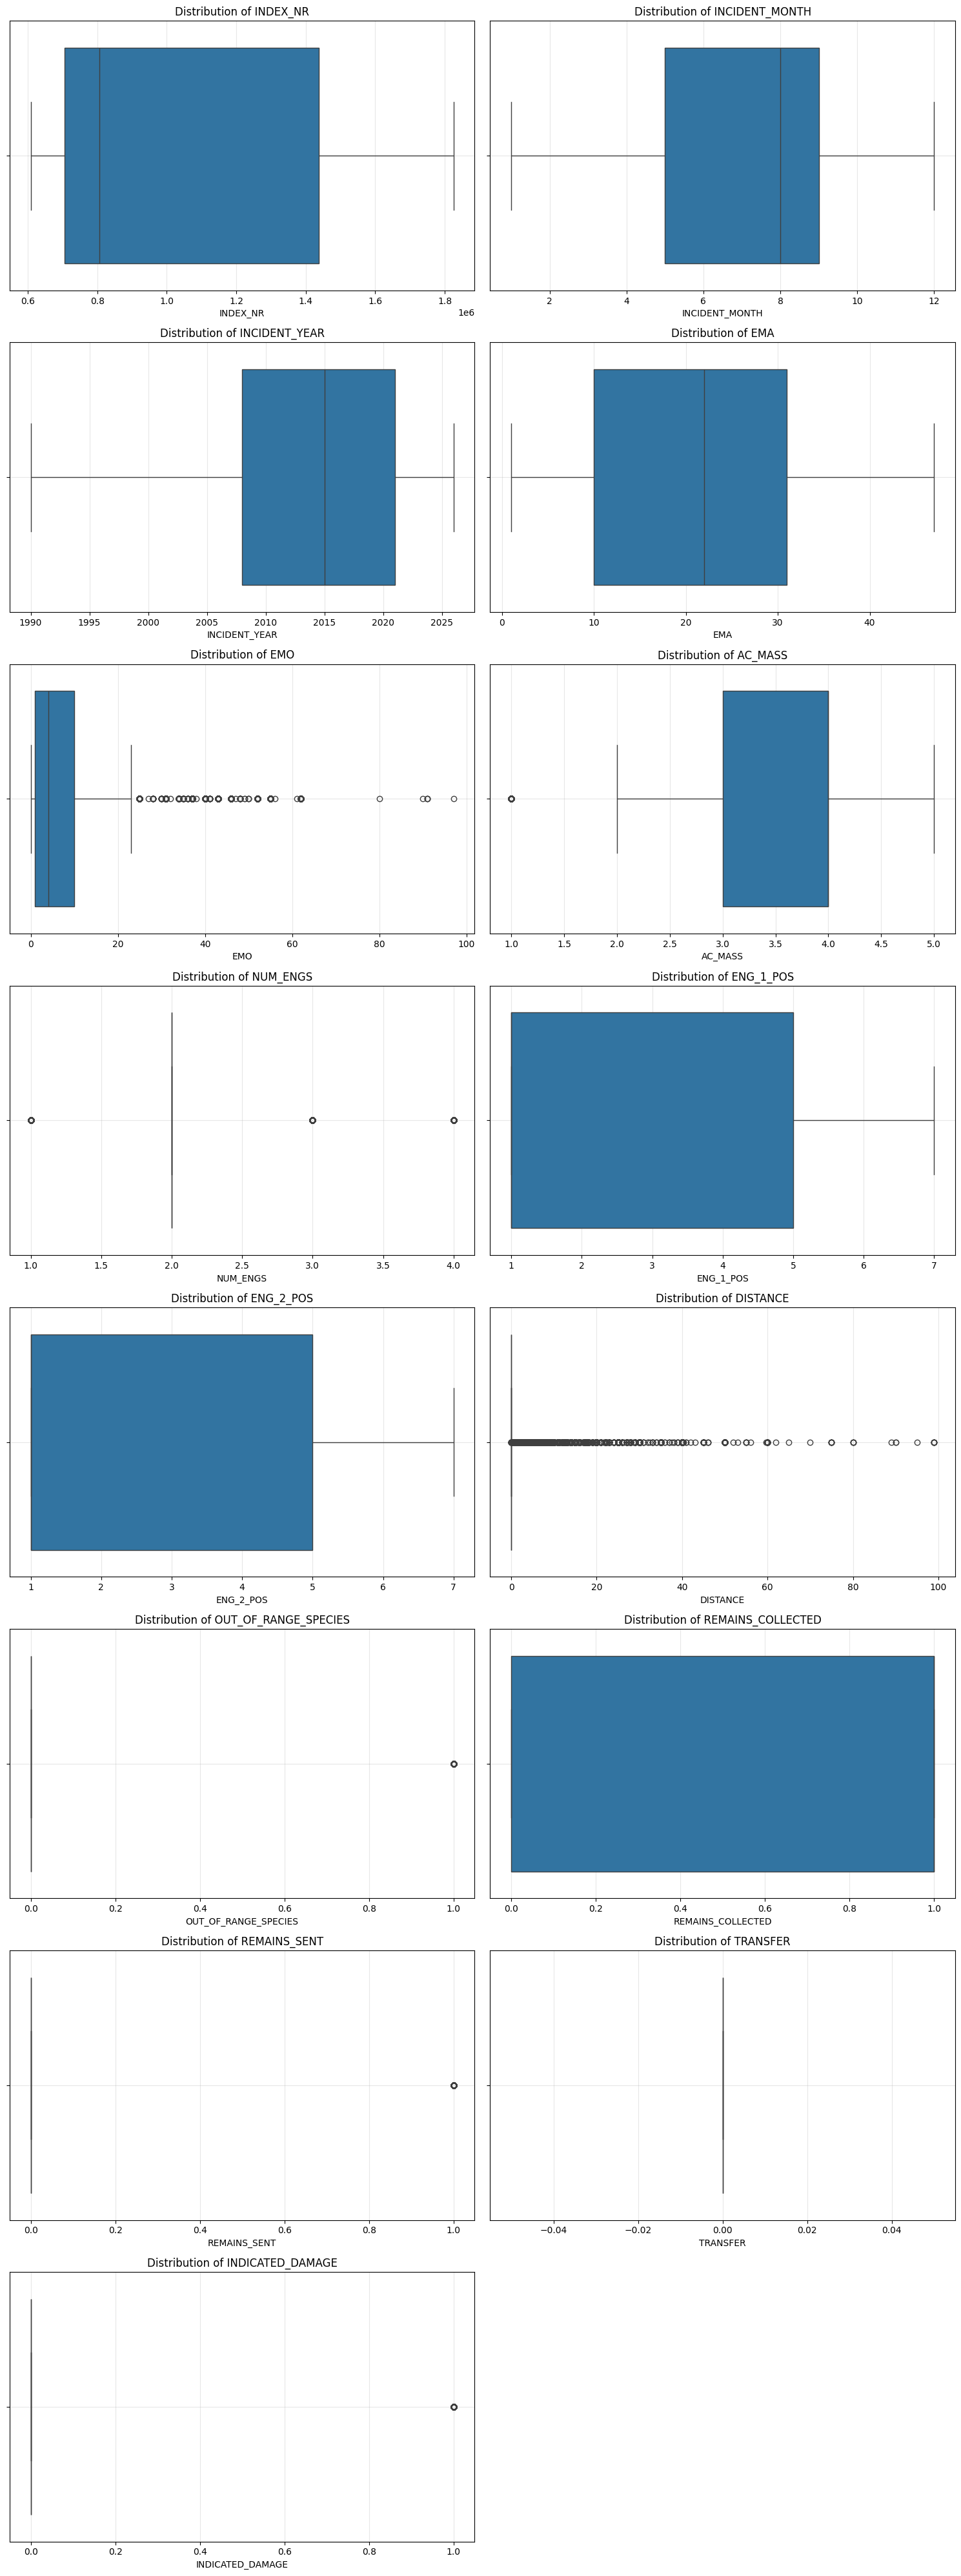

In [ ]:
# Identify numerical columns for outlier detection. Although it does not work well for binary features like REMAINS_COLLECTED
num_cols = df_cleaned.select_dtypes(include=['number']).columns

# Set up the plotting grid
n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols):
    # Plotting Boxplot to see outliers clearly
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_cleaned[col])
    plt.title(f'Distribution of {col}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Here we wanted to see the indicated damadge made when remains were sent or not
df['REMAINS_SENT'].value_counts()

,count
REMAINS_SENT,
0,251941
1,55237


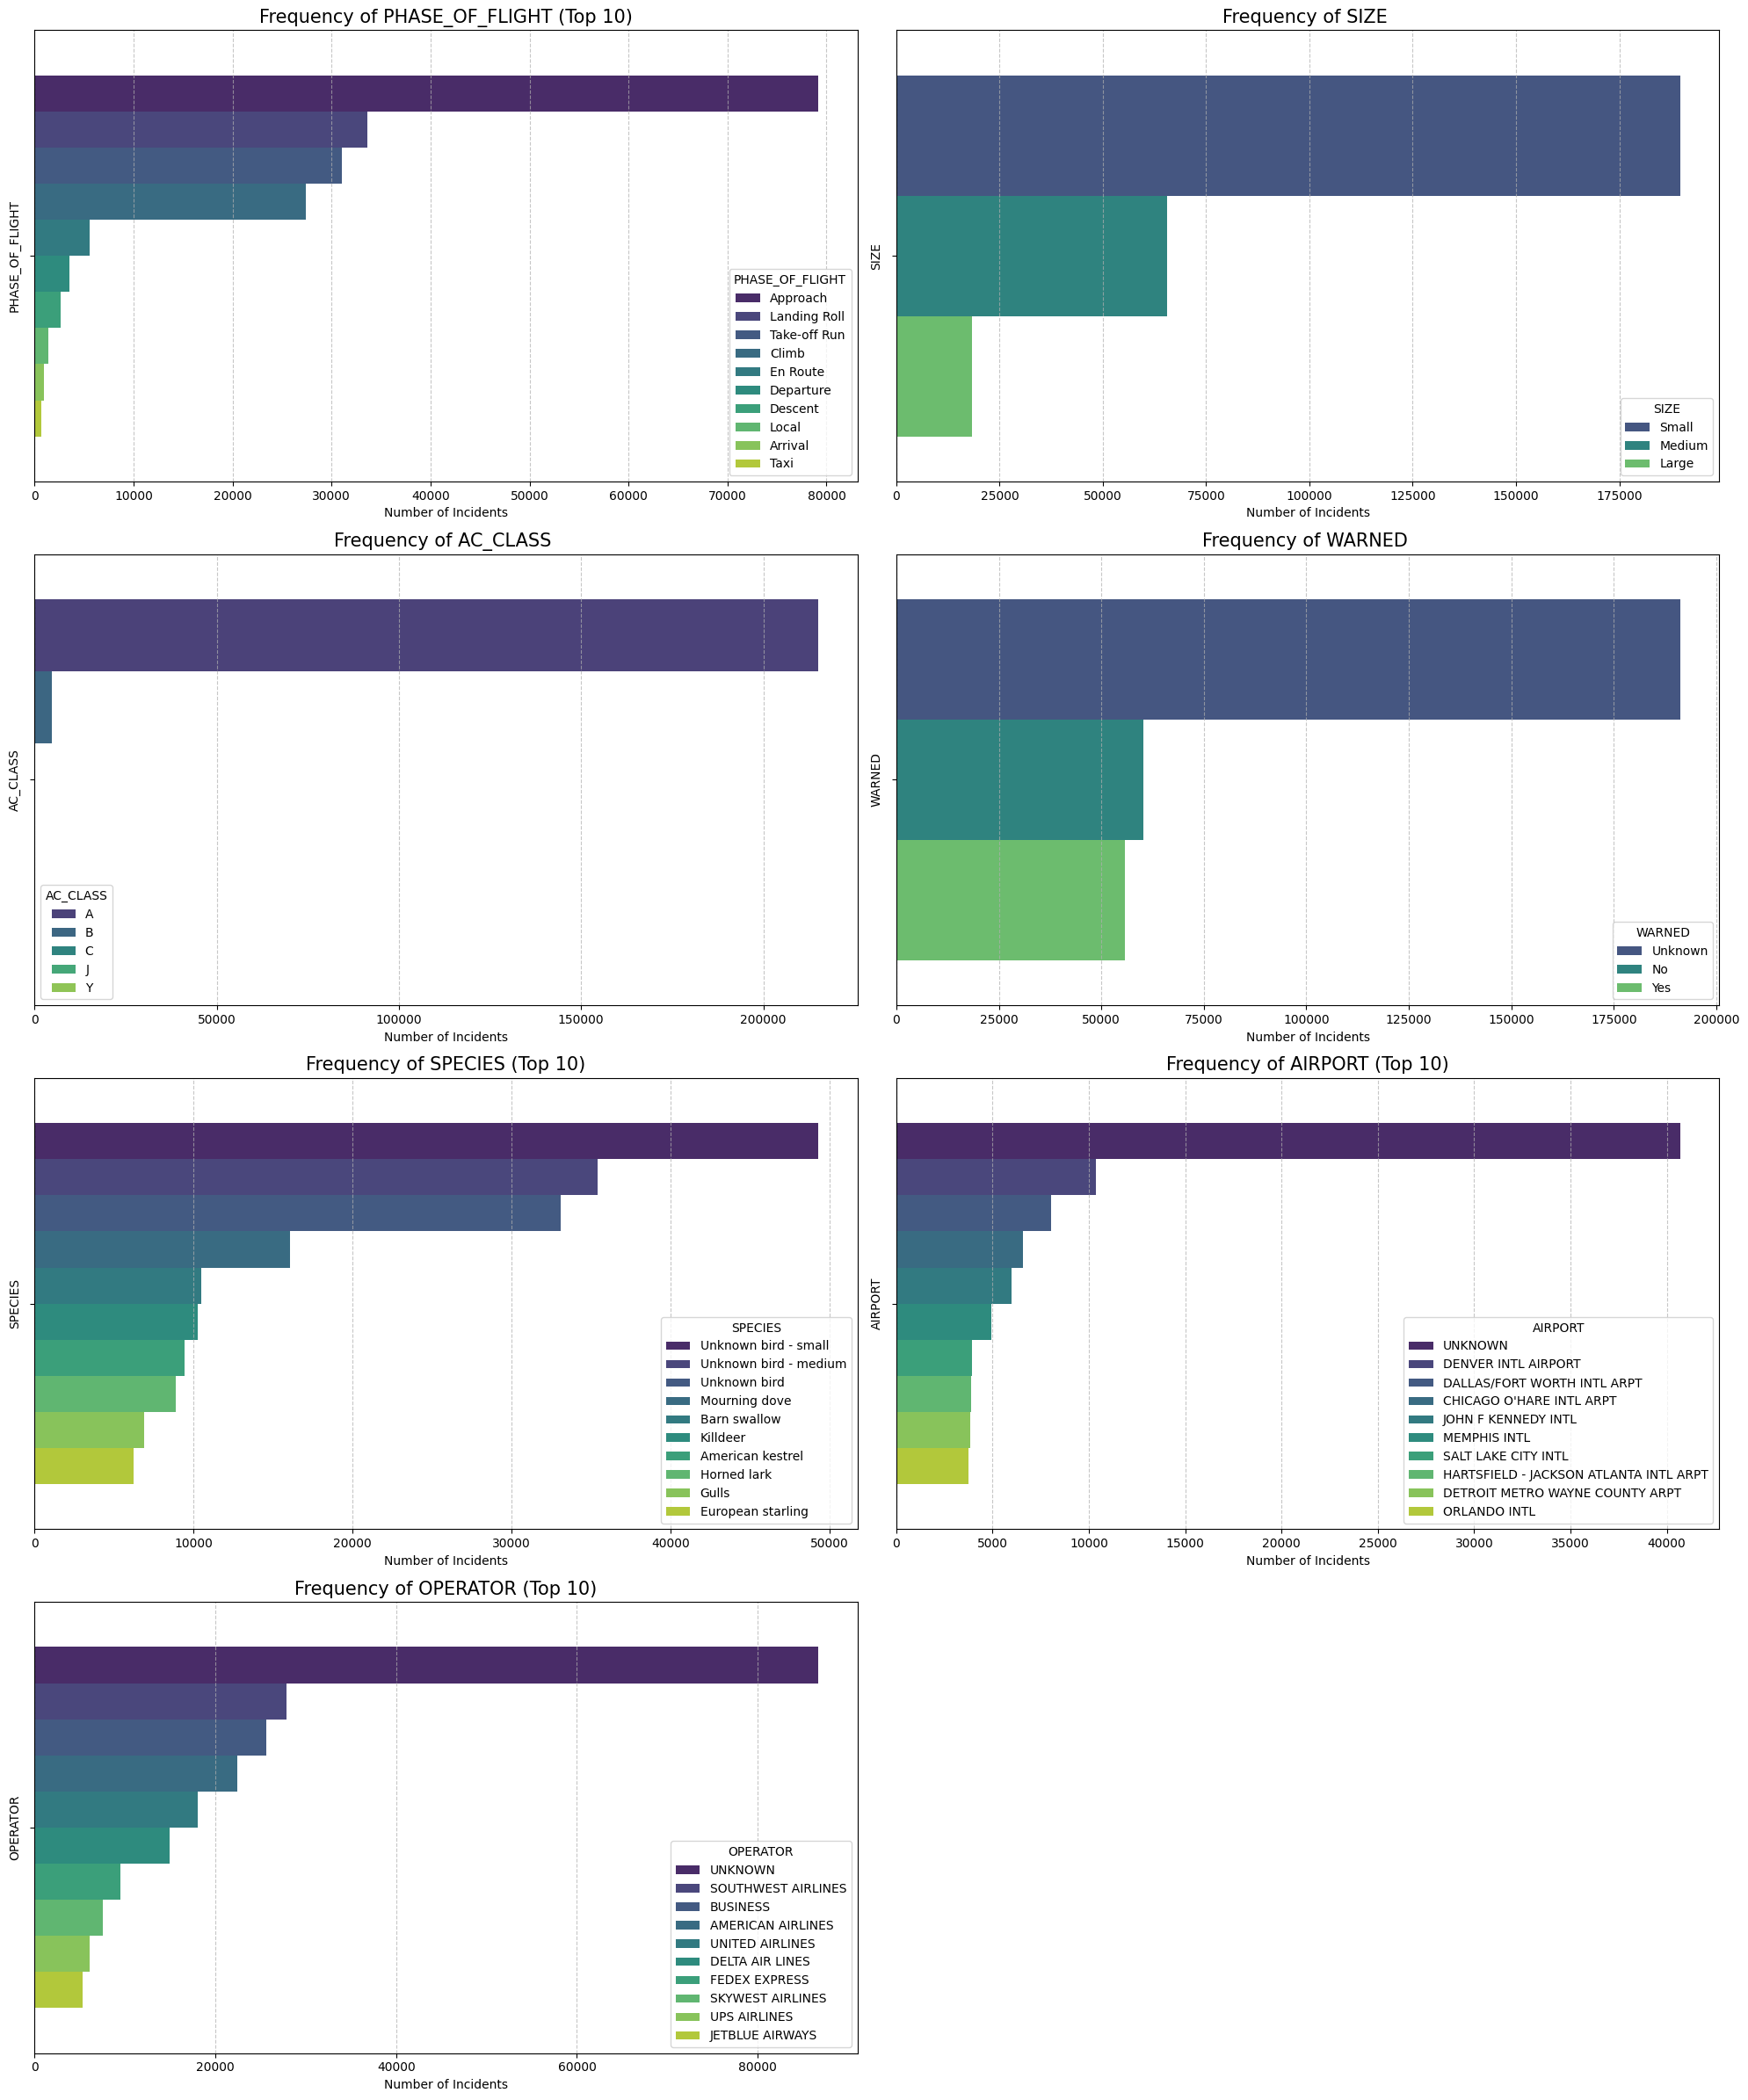

In [ ]:
# List of interesting categorical columns to visualize
categorical_features = [
    'PHASE_OF_FLIGHT', 'SIZE', 'AC_CLASS', 'WARNED',
    'SPECIES', 'AIRPORT', 'OPERATOR'
]

# Set up the plotting grid
n_cols = 2
n_rows = (len(categorical_features) + 1) // n_cols
plt.figure(figsize=(20, 6 * n_rows))

for i, col in enumerate(categorical_features):
    plt.subplot(n_rows, n_cols, i + 1)

    # For columns with many unique values, only show the Top 10
    if df_cleaned[col].nunique() > 10:
        data_to_plot = df_cleaned[col].value_counts().head(10)
        title_suffix = "(Top 10)"
    else:
        data_to_plot = df_cleaned[col].value_counts()
        title_suffix = ""

    # Create the bar chart
    sns.barplot(x=data_to_plot.values, hue=data_to_plot.index, palette='viridis')

    plt.title(f'Frequency of {col} {title_suffix}', fontsize=15)
    plt.xlabel('Number of Incidents')
    plt.ylabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Plotting 20 categorical features: ['AIRPORT', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'OPID', 'OPERATOR', 'AIRCRAFT', 'AMA', 'AMO', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SPECIES', 'WARNED', 'NUM_STRUCK', 'SIZE', 'SOURCE', 'PERSON']


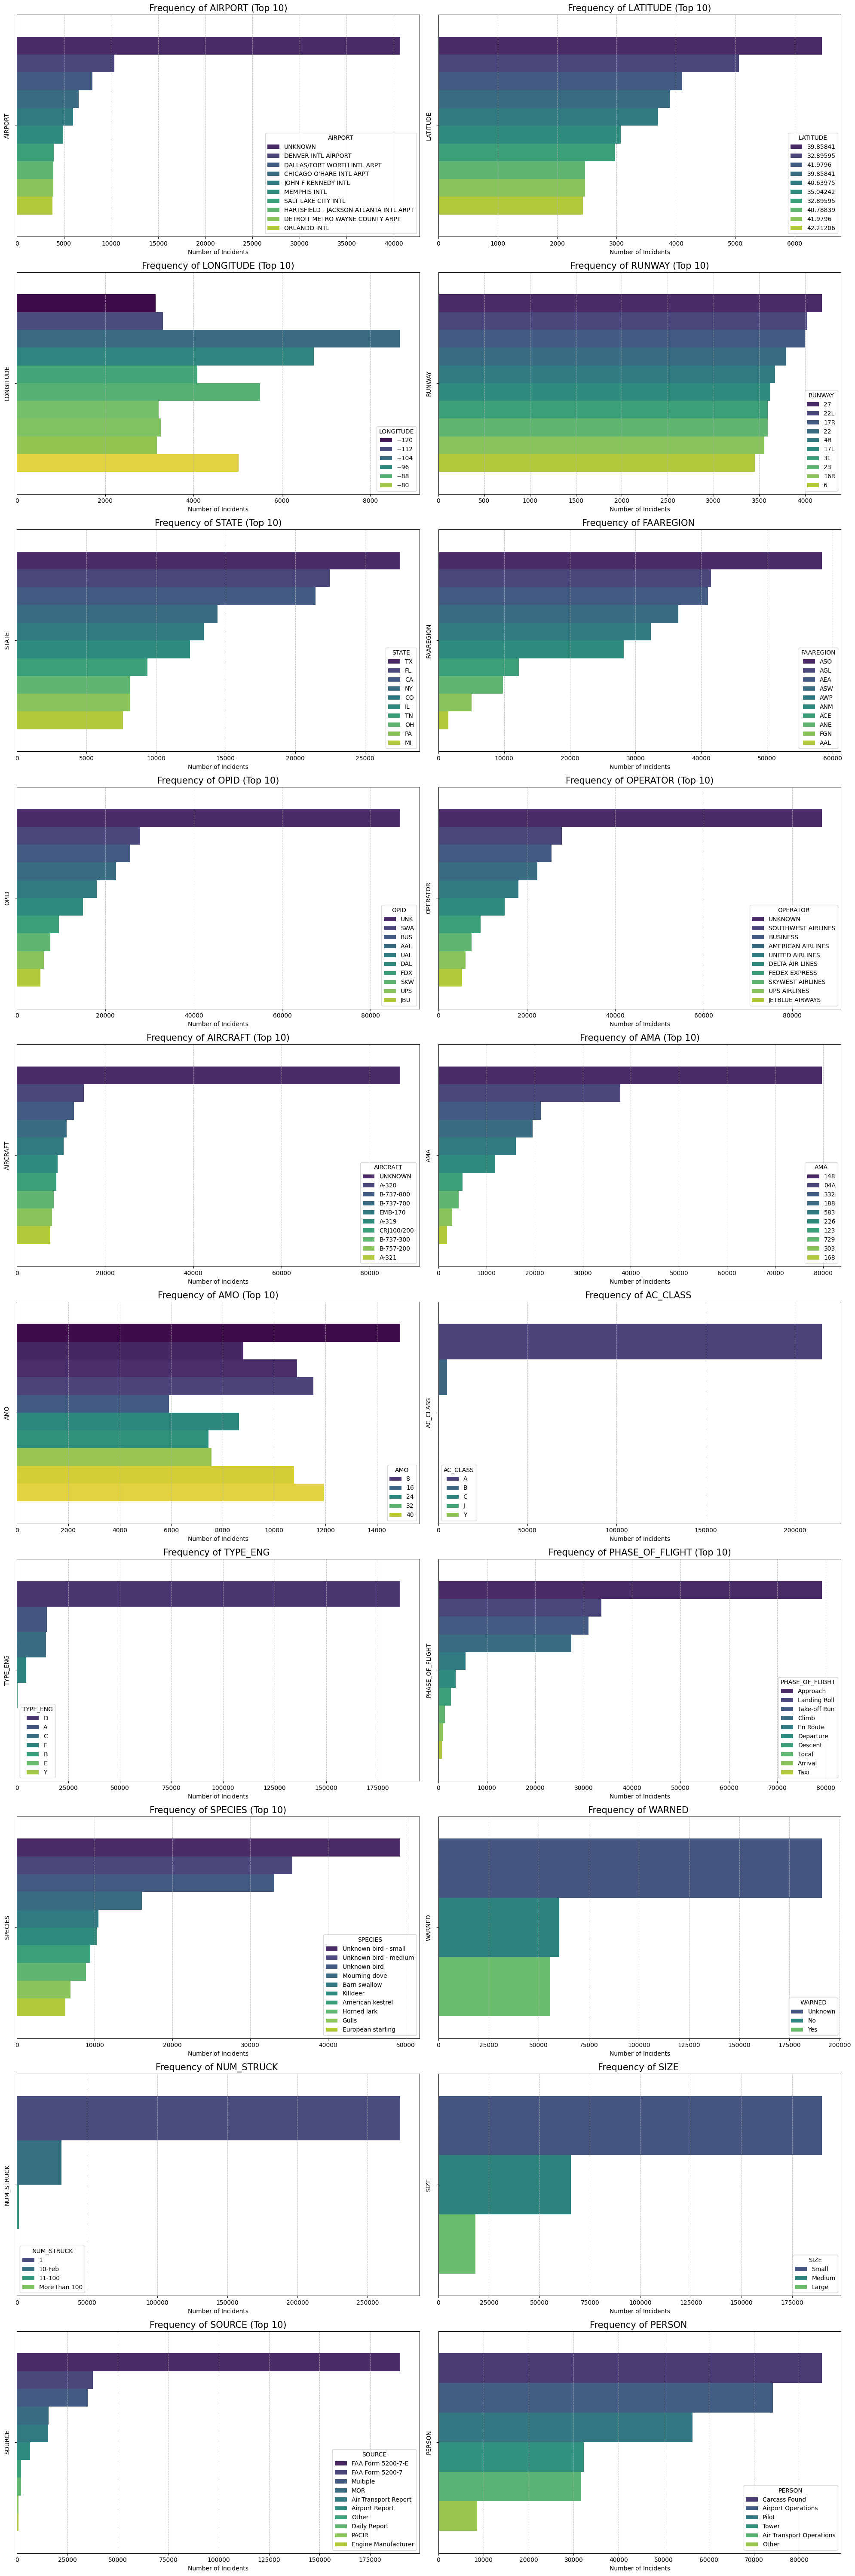

In [ ]:
# Plotting all remaining categorical features for df_cleaned

# Get all non-numerical columns
all_non_numerical_cols = df_cleaned.select_dtypes(exclude=['number']).columns.tolist()

# Columns to explicitly exclude from plotting (dates, free text, high-cardinality IDs)
exclude_from_plotting = [
    'INCIDENT_DATE', 'AIRPORT_ID', 'REG', 'SPECIES_ID', 'REMARKS', 'COMMENTS', 'LUPDATE'
]

# Filter the list to get relevant categorical features for plotting
categorical_features_to_plot = [
    col for col in all_non_numerical_cols if col not in exclude_from_plotting
]

print(f"Plotting {len(categorical_features_to_plot)} categorical features: {categorical_features_to_plot}")

# Set up the plotting grid
n_cols = 2
n_rows = (len(categorical_features_to_plot) + 1) // n_cols
plt.figure(figsize=(20, 6 * n_rows))

for i, col in enumerate(categorical_features_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)

    # For columns with many unique values, only show the Top 10
    if df_cleaned[col].nunique() > 10:
        data_to_plot = df_cleaned[col].value_counts().head(10)
        title_suffix = "(Top 10)"
    else:
        data_to_plot = df_cleaned[col].value_counts()
        title_suffix = ""

    # Create the bar chart
    sns.barplot(x=data_to_plot.values, hue=data_to_plot.index, palette='viridis')

    plt.title(f'Frequency of {col} {title_suffix}', fontsize=15)
    plt.xlabel('Number of Incidents')
    plt.ylabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

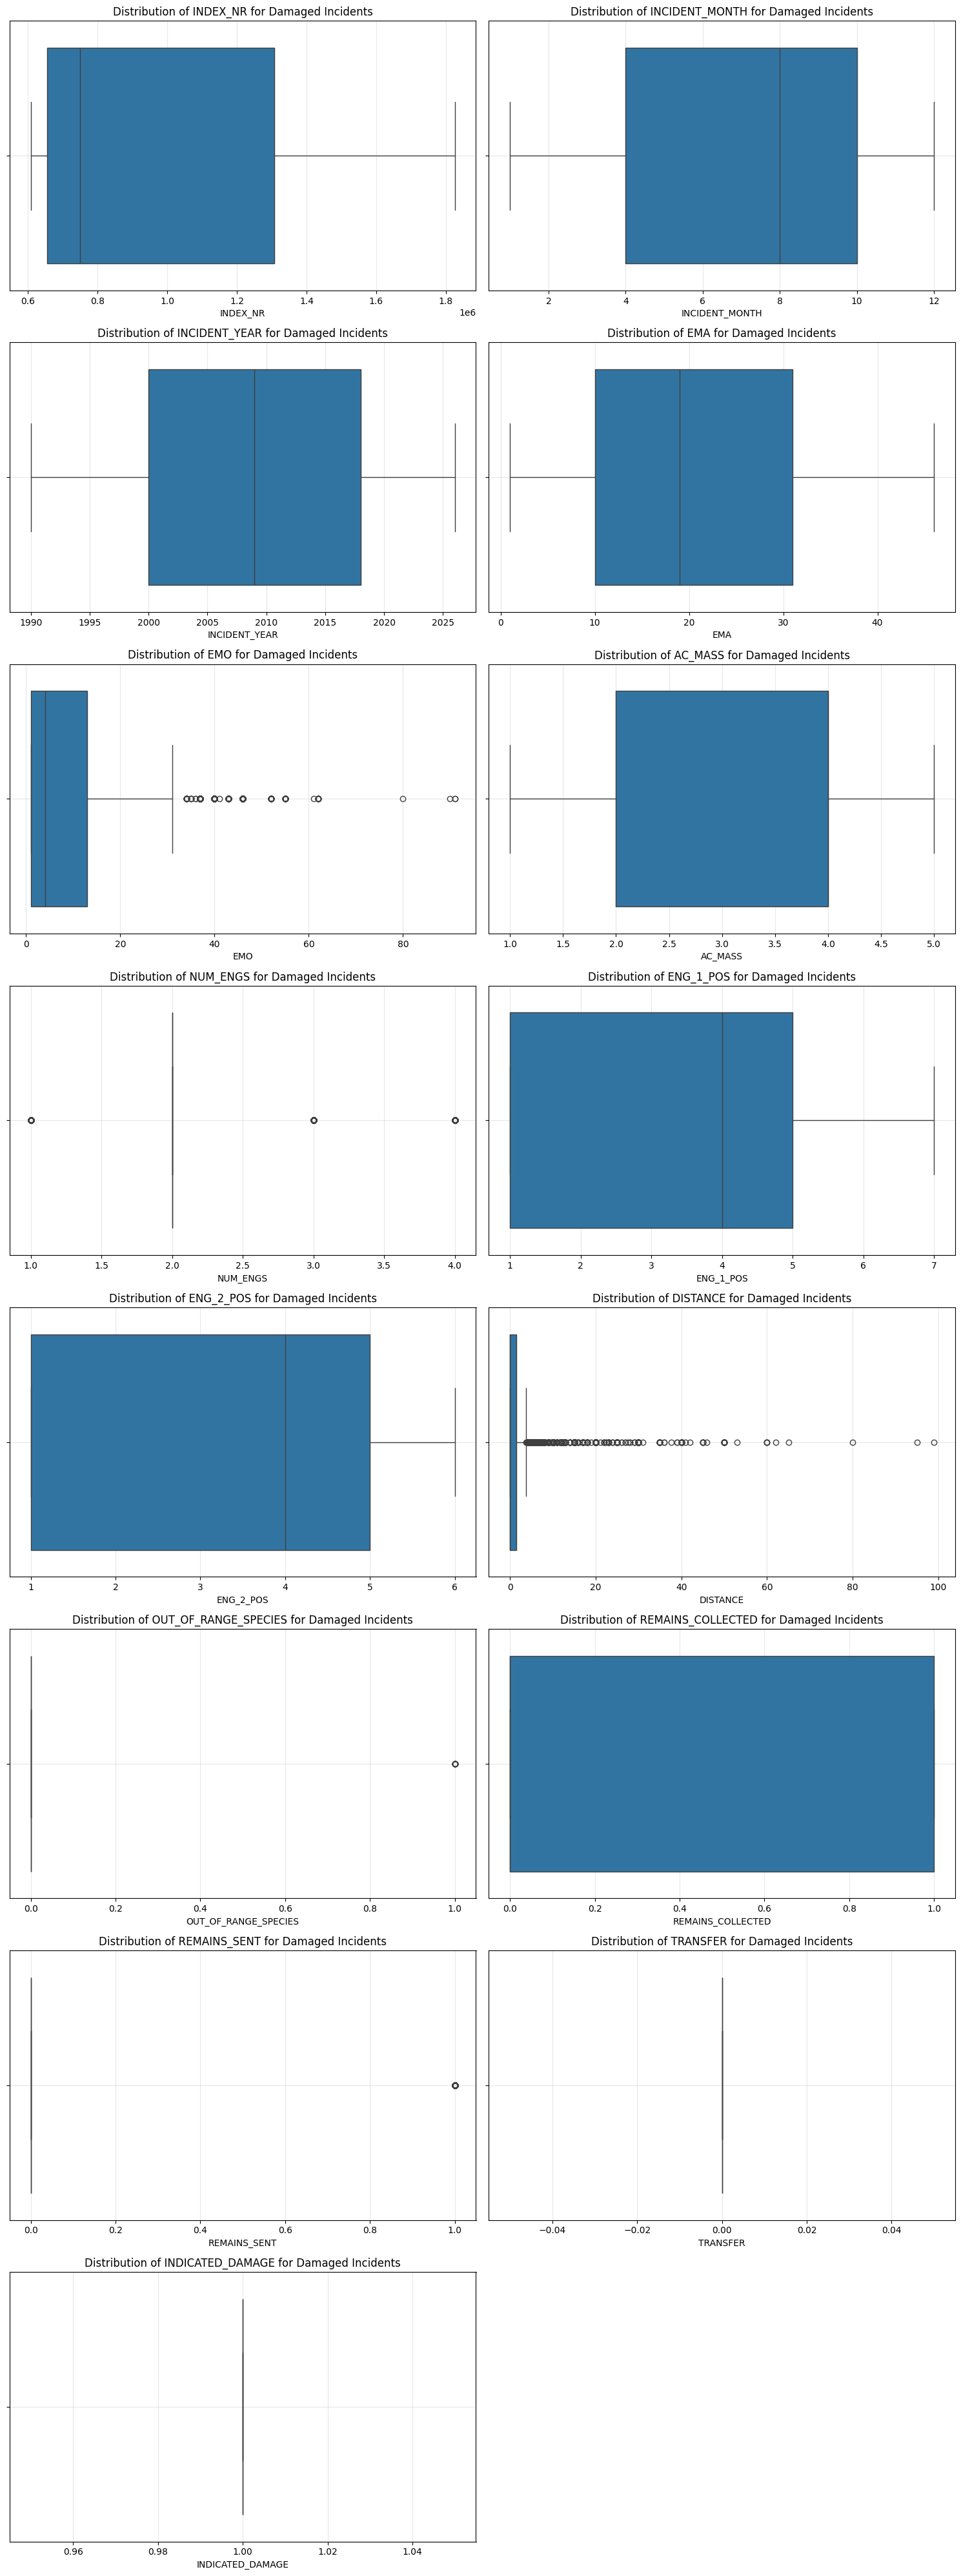

In [ ]:
# lets begin looking at the distributions of each column.
# Filter the DataFrame for incidents where INDICATED_DAMAGE = 1
df_damaged = df_cleaned[df_cleaned['INDICATED_DAMAGE'] == 1]

# Identify numerical columns for outlier detection
num_cols = df_damaged.select_dtypes(include=['number']).columns

# Set up the plotting grid
n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols):
    # Plotting Boxplot to see outliers clearly
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_damaged[col])
    plt.title(f'Distribution of {col} for Damaged Incidents')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

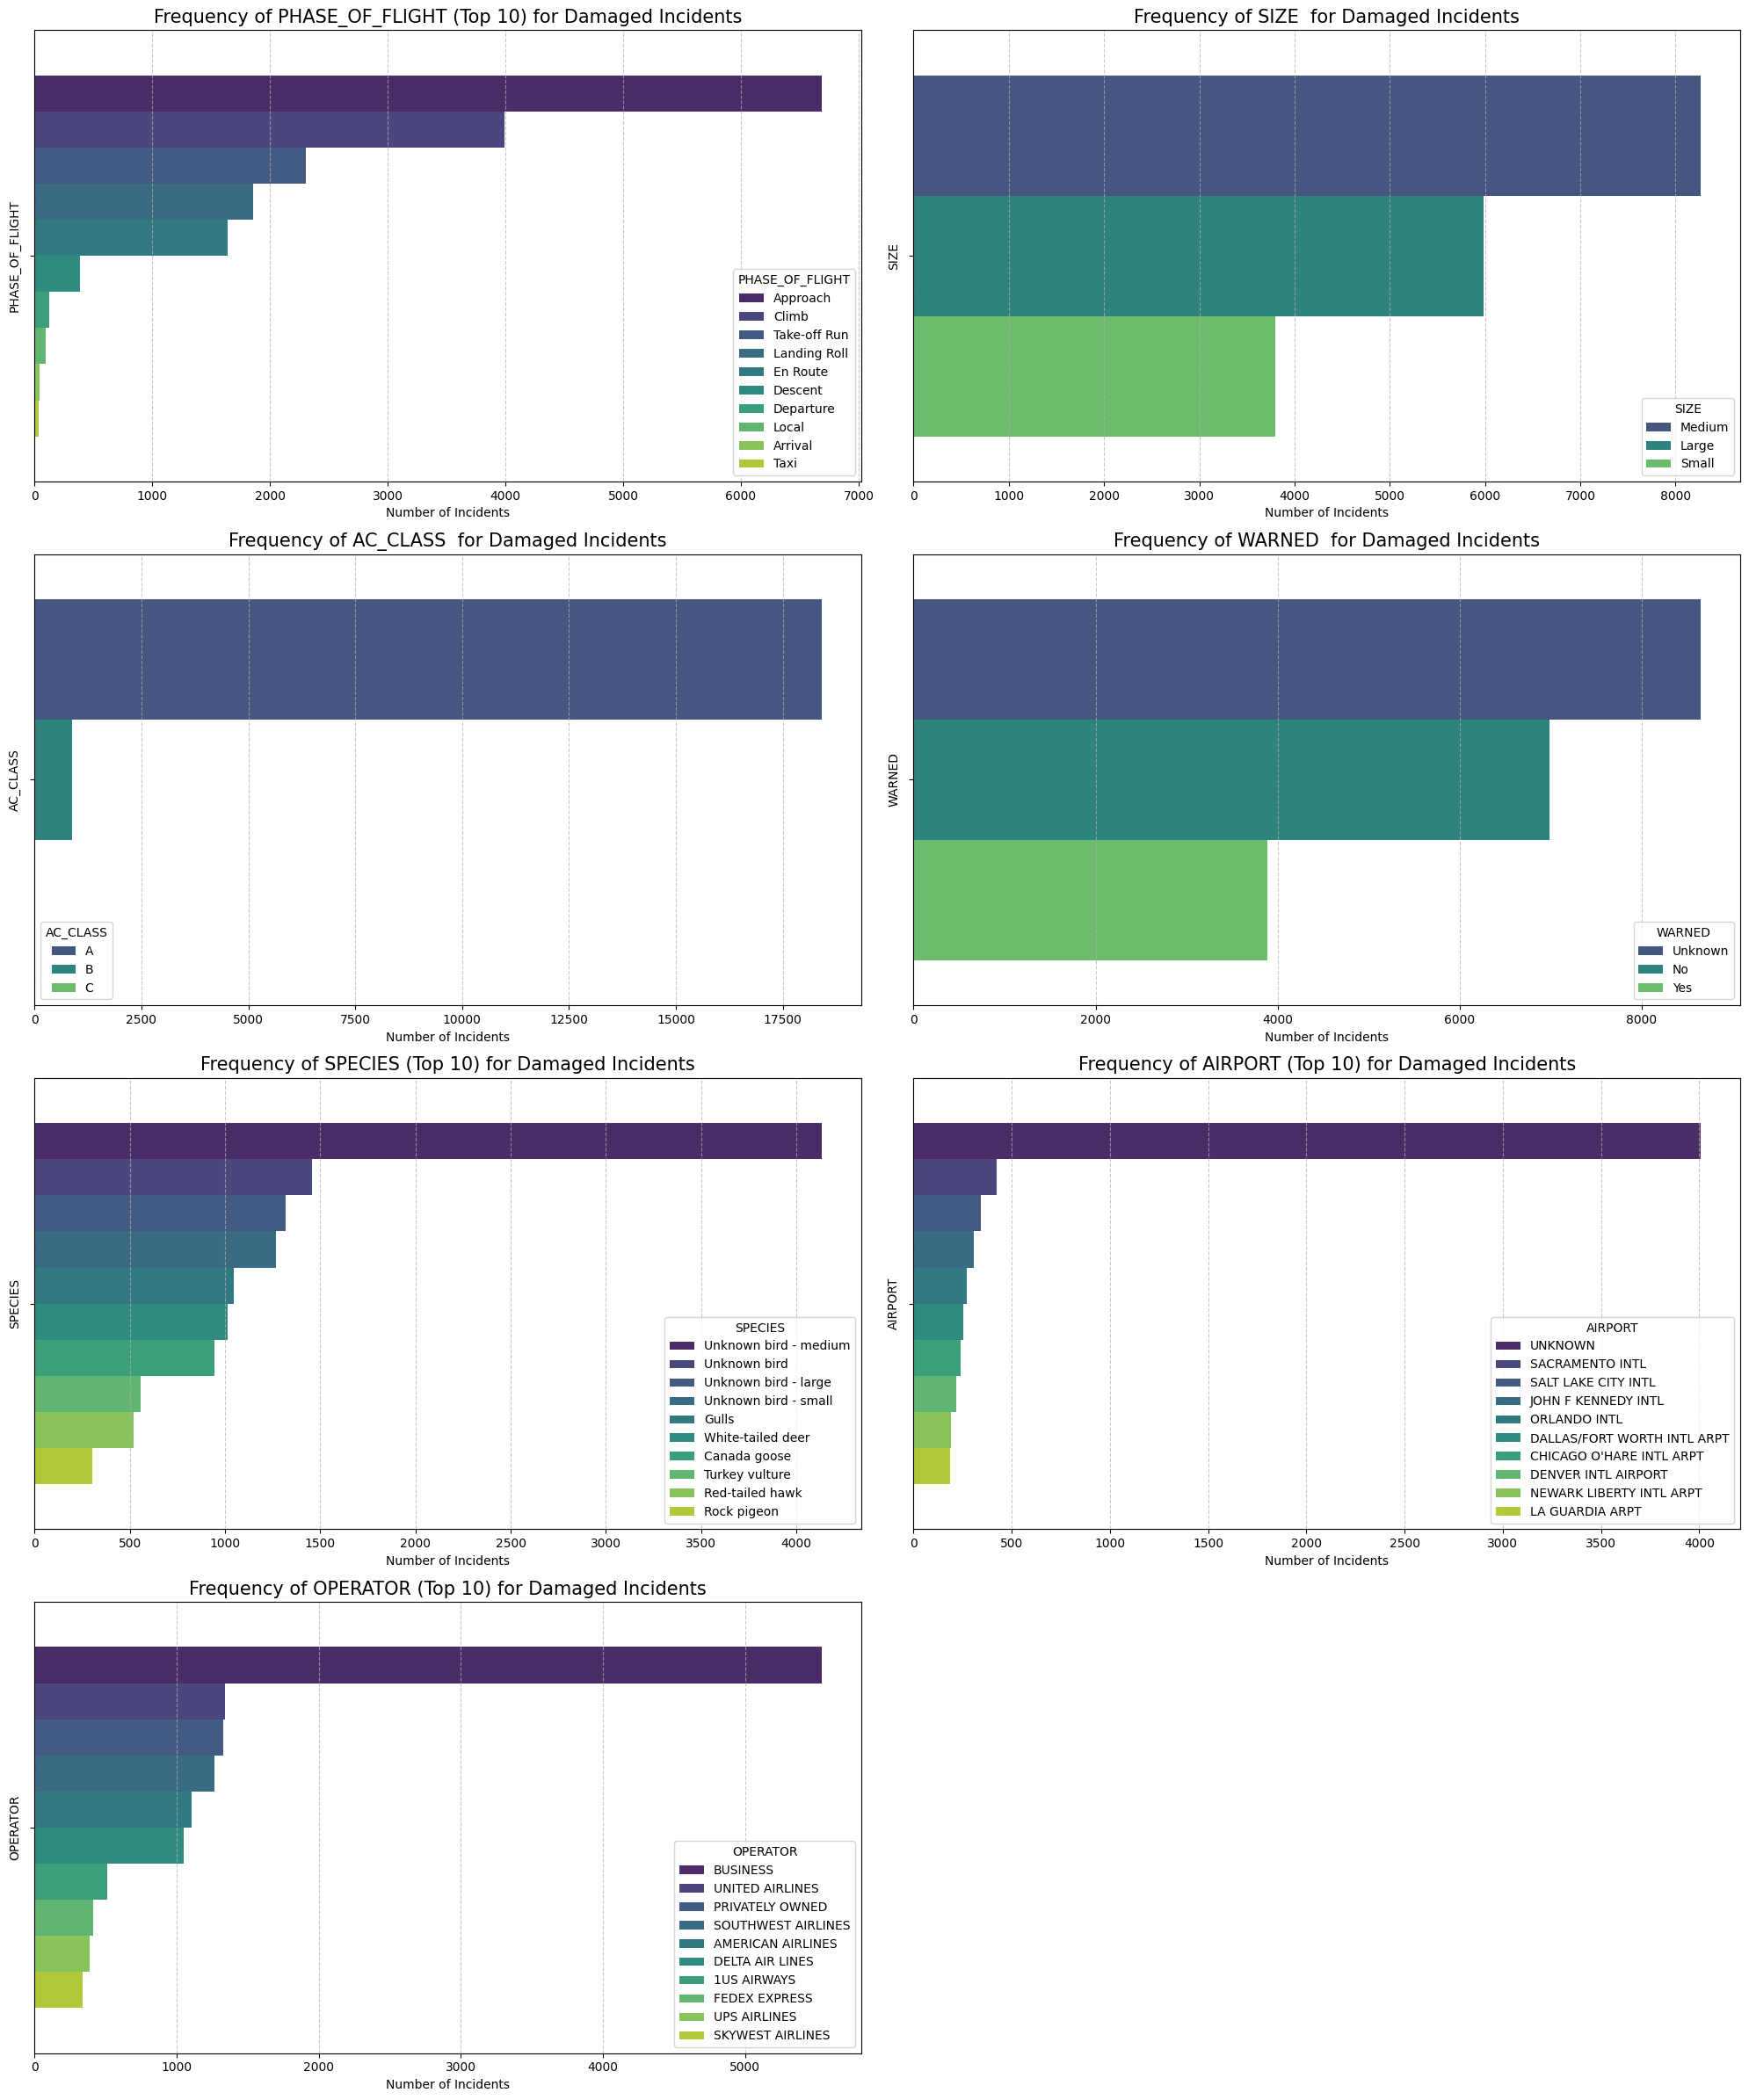

In [ ]:
# now lets go ahead and show the catergorical data for damaged incidents
# List of interesting categorical columns to visualize
categorical_features = [
    'PHASE_OF_FLIGHT', 'SIZE', 'AC_CLASS', 'WARNED',
    'SPECIES', 'AIRPORT', 'OPERATOR'
]

# Set up the plotting grid
n_cols = 2
n_rows = (len(categorical_features) + 1) // n_cols
plt.figure(figsize=(20, 6 * n_rows))

for i, col in enumerate(categorical_features):
    plt.subplot(n_rows, n_cols, i + 1)

    # For columns with many unique values, only show the Top 10
    if df_damaged[col].nunique() > 10:
        data_to_plot = df_damaged[col].value_counts().head(10)
        title_suffix = "(Top 10)"
    else:
        data_to_plot = df_damaged[col].value_counts()
        title_suffix = ""

    # Create the bar chart
    sns.barplot(x=data_to_plot.values, hue=data_to_plot.index, palette='viridis')

    plt.title(f'Frequency of {col} {title_suffix} for Damaged Incidents', fontsize=15)
    plt.xlabel('Number of Incidents')
    plt.ylabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Plotting 20 categorical features: ['AIRPORT', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'OPID', 'OPERATOR', 'AIRCRAFT', 'AMA', 'AMO', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SPECIES', 'WARNED', 'NUM_STRUCK', 'SIZE', 'SOURCE', 'PERSON']


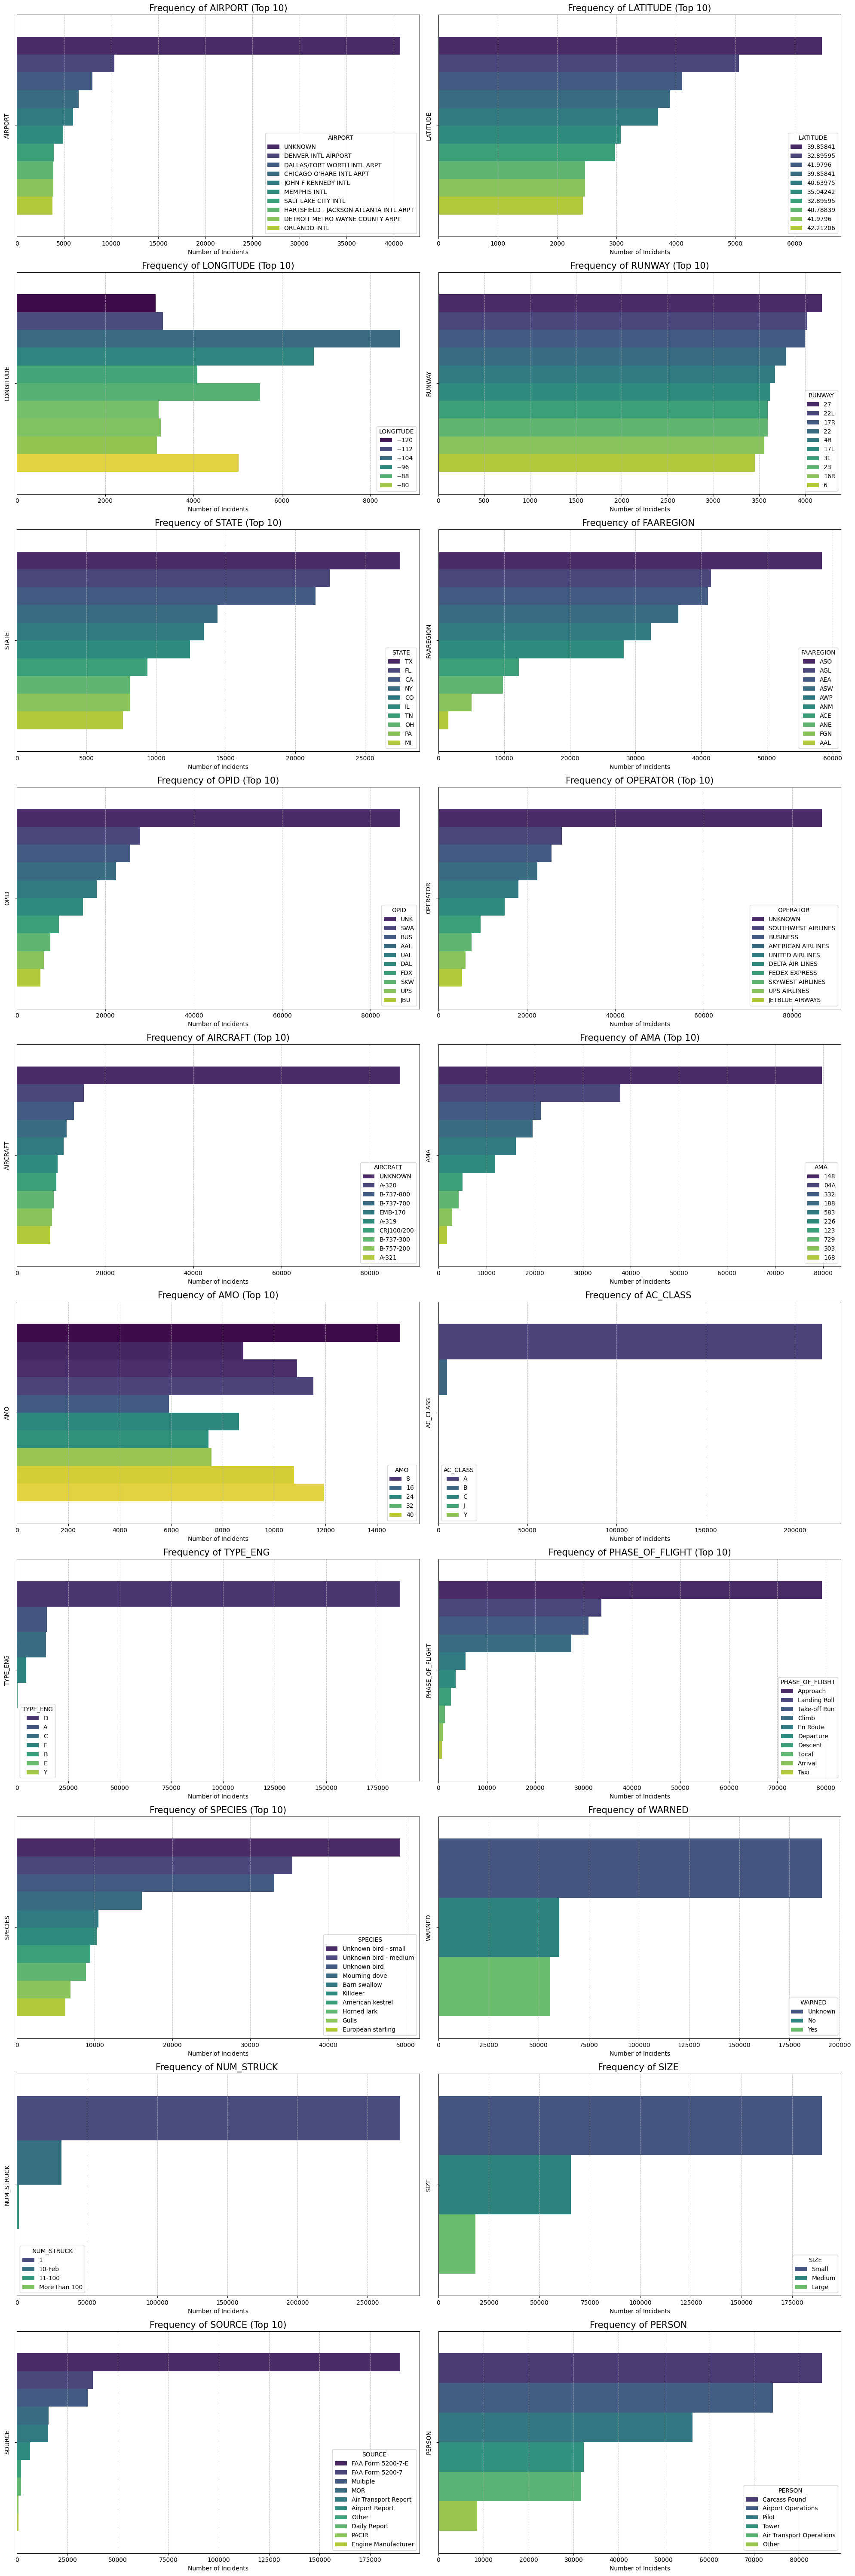

In [ ]:
# Plotting all remaining categorical features for df_cleaned

# Get all non-numerical columns
all_non_numerical_cols = df_cleaned.select_dtypes(exclude=['number']).columns.tolist()

# Columns to explicitly exclude from plotting (dates, free text, high-cardinality IDs)
exclude_from_plotting = [
    'INCIDENT_DATE', 'AIRPORT_ID', 'REG', 'SPECIES_ID', 'REMARKS', 'COMMENTS', 'LUPDATE'
]

# Filter the list to get relevant categorical features for plotting
categorical_features_to_plot = [
    col for col in all_non_numerical_cols if col not in exclude_from_plotting
]

print(f"Plotting {len(categorical_features_to_plot)} categorical features: {categorical_features_to_plot}")

# Set up the plotting grid
n_cols = 2
n_rows = (len(categorical_features_to_plot) + 1) // n_cols
plt.figure(figsize=(20, 6 * n_rows))

for i, col in enumerate(categorical_features_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)

    # For columns with many unique values, only show the Top 10
    if df_cleaned[col].nunique() > 10:
        data_to_plot = df_cleaned[col].value_counts().head(10)
        title_suffix = "(Top 10)"
    else:
        data_to_plot = df_cleaned[col].value_counts()
        title_suffix = ""

    # Create the bar chart
    sns.barplot(x=data_to_plot.values, hue=data_to_plot.index, palette='viridis')

    plt.title(f'Frequency of {col} {title_suffix}', fontsize=15)
    plt.xlabel('Number of Incidents')
    plt.ylabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Plotting 20 categorical features: ['AIRPORT', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'OPID', 'OPERATOR', 'AIRCRAFT', 'AMA', 'AMO', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SPECIES', 'WARNED', 'NUM_STRUCK', 'SIZE', 'SOURCE', 'PERSON']


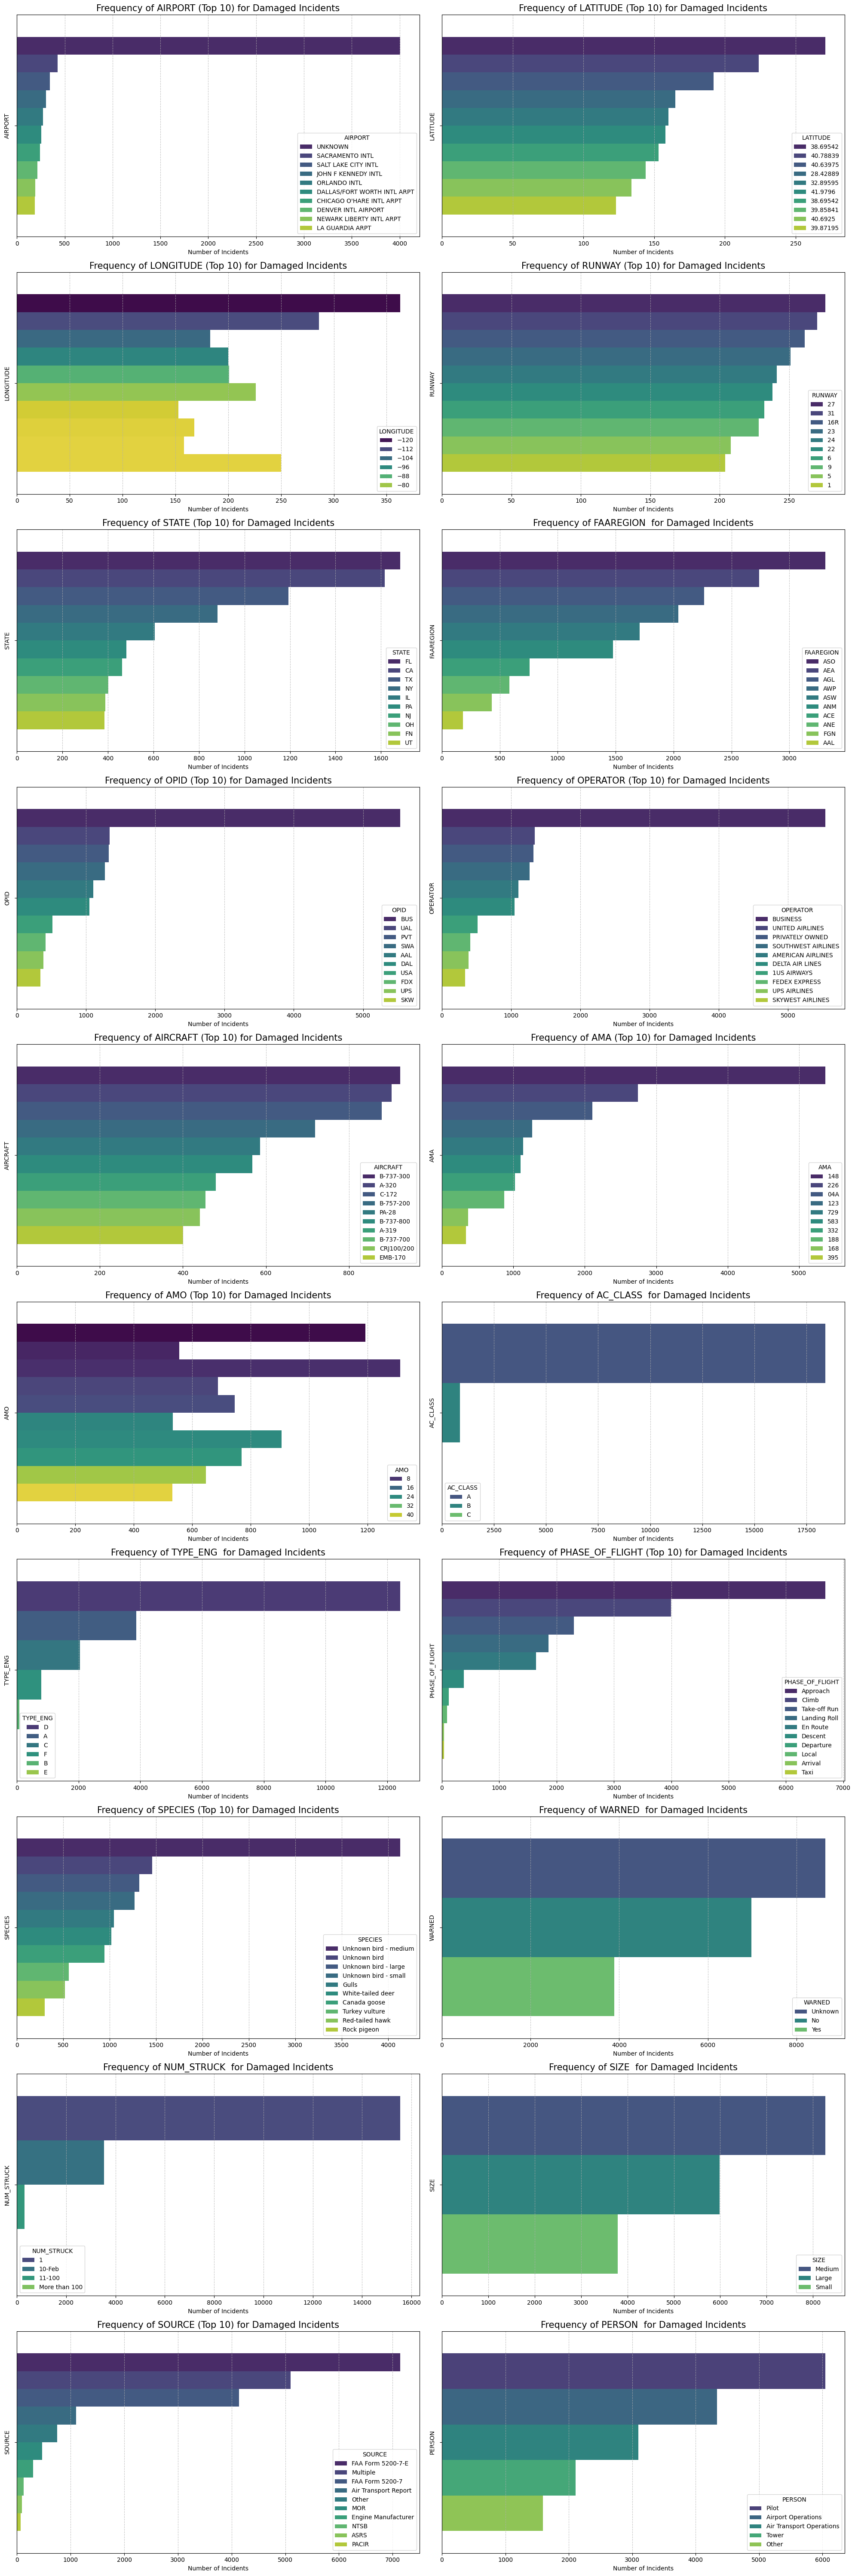

In [ ]:
# Plotting all remaining categorical features for df_damaged

# Get all non-numerical columns
all_non_numerical_cols = df_damaged.select_dtypes(exclude=['number']).columns.tolist()

# Columns to explicitly exclude from plotting (dates, free text, high-cardinality IDs)
exclude_from_plotting = [
    'INCIDENT_DATE', 'AIRPORT_ID', 'REG', 'SPECIES_ID', 'REMARKS', 'COMMENTS', 'LUPDATE'
]

# Filter the list to get relevant categorical features for plotting
categorical_features_to_plot = [
    col for col in all_non_numerical_cols if col not in exclude_from_plotting
]

print(f"Plotting {len(categorical_features_to_plot)} categorical features: {categorical_features_to_plot}")

# Set up the plotting grid
n_cols = 2
n_rows = (len(categorical_features_to_plot) + 1) // n_cols
plt.figure(figsize=(20, 6 * n_rows))

for i, col in enumerate(categorical_features_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)

    # For columns with many unique values, only show the Top 10
    if df_damaged[col].nunique() > 10:
        data_to_plot = df_damaged[col].value_counts().head(10)
        title_suffix = "(Top 10)"
    else:
        data_to_plot = df_damaged[col].value_counts()
        title_suffix = ""

    # Create the bar chart
    sns.barplot(x=data_to_plot.values, hue=data_to_plot.index, palette='viridis')

    plt.title(f'Frequency of {col} {title_suffix} for Damaged Incidents', fontsize=15)
    plt.xlabel('Number of Incidents')
    plt.ylabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Nina: maybe drop these categories because their majority data type is unknown or the same data: AC_CLASS, and AIRPORT, AIRCRAFT, OPERATOR, and OPID

In [ ]:
df_cleaned = df_cleaned.drop(columns=['AC_CLASS', 'AIRPORT', 'AIRCRAFT', 'OPERATOR', 'OPID'])
df_cleaned.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,AIRPORT_ID,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,...,REMAINS_SENT,WARNED,NUM_STRUCK,SIZE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,TJSJ,18.43942,-66.00183,7,PR,ASO,...,0,No,10-Feb,Small,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,WMKK,2.745578,101.709917,32R,FN,FGN,...,0,Unknown,1,Medium,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,KSDF,38.17439,-85.736,35L,KY,ASO,...,0,No,1,Large,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,KLAX,33.94254,-118.40807,25R,CA,AWP,...,0,Unknown,10-Feb,Medium,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,PHLI,21.97598,-159.33896,35,HI,AWP,...,0,No,1,Medium,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


In [ ]:
# Gets the percentage of missing values per feature AGAIN. lower better
nan_percentages = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100
print(nan_percentages)

INDEX_NR                 0.000000
INCIDENT_DATE            0.000000
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
AIRPORT_ID               0.000000
LATITUDE                13.263971
LONGITUDE               13.264947
RUNWAY                  24.606254
STATE                   13.263971
FAAREGION               13.263971
REG                     38.733894
AMA                     28.939572
AMO                     38.027788
EMA                     33.342557
EMO                     36.843784
AC_MASS                 28.467533
TYPE_ENG                28.578218
NUM_ENGS                28.549245
ENG_1_POS               28.555756
ENG_2_POS               33.371205
PHASE_OF_FLIGHT         39.378146
DISTANCE                33.629687
SPECIES_ID               0.000000
SPECIES                  0.000000
OUT_OF_RANGE_SPECIES     0.000000
REMARKS                 11.489755
REMAINS_COLLECTED        0.000000
REMAINS_SENT             0.000000
WARNED                   0.000000
NUM_STRUCK    

Based on the print of the head above this, we are seeing a row that has majority null values. we want to search how many of these rows that have more than half of their columns missing then drop them if possible.

In [ ]:
total_records = len(df_cleaned)
total_columns = len(df_cleaned.columns)
missing_per_row = df_cleaned.isnull().sum(axis=1)

print(f"Total records in dataset: {total_records}")
print(f"Total columns in df_cleaned: {total_columns}")
print(f"Total records with Damage (1): {df_cleaned['INDICATED_DAMAGE'].sum()}")
print(f"Total records without Damage (0): {(df_cleaned['INDICATED_DAMAGE'] == 0).sum()}\n")

# Loop for every threshold starting at 18 and going down to 10
for threshold in range(18, 9, -1):
    mask_exceeding = missing_per_row > threshold
    records_exceeding = mask_exceeding.sum()
    percent_missing_cols = (threshold / total_columns) * 100

    # Get distribution of target variable for dropped rows
    target_dist = df_cleaned.loc[mask_exceeding, 'INDICATED_DAMAGE'].value_counts()
    damage_1 = target_dist.get(1, 0)
    damage_0 = target_dist.get(0, 0)

    print(f"Threshold: >{threshold} missing columns ({percent_missing_cols:.1f}% of columns)")
    print(f"  -> Records to drop: {records_exceeding} ({(records_exceeding / total_records) * 100:.3f}% of total)")
    print(f"  -> Target dist in dropped: Damage=1: {damage_1}, Damage=0: {damage_0}\n")

Total records in dataset: 307178
Total columns in df_cleaned: 37
Total records with Damage (1): 19527
Total records without Damage (0): 287651

Threshold: >18 missing columns (48.6% of columns)
  -> Records to drop: 38 (0.012% of total)
  -> Target dist in dropped: Damage=1: 1, Damage=0: 37

Threshold: >17 missing columns (45.9% of columns)
  -> Records to drop: 136 (0.044% of total)
  -> Target dist in dropped: Damage=1: 6, Damage=0: 130

Threshold: >16 missing columns (43.2% of columns)
  -> Records to drop: 257 (0.084% of total)
  -> Target dist in dropped: Damage=1: 13, Damage=0: 244

Threshold: >15 missing columns (40.5% of columns)
  -> Records to drop: 307 (0.100% of total)
  -> Target dist in dropped: Damage=1: 26, Damage=0: 281

Threshold: >14 missing columns (37.8% of columns)
  -> Records to drop: 354 (0.115% of total)
  -> Target dist in dropped: Damage=1: 48, Damage=0: 306

Threshold: >13 missing columns (35.1% of columns)
  -> Records to drop: 604 (0.197% of total)
  -> T

We printed the amount of missing data per threshold of missing columns. From there we also printed how many of each target column there was and how much if we did drop the rows, how much % of the data we would lose.

Based on the findings, we want to drop any rows that have more than 12 columns missing (32.4% of columns) so that we get impute less data and get rid of records that are missing over that 32.4%.

We are now going to drop the data :>

In [ ]:
missing_per_row = df_cleaned.isnull().sum(axis=1)
mask_to_drop = missing_per_row > 12

# Calculate counts for reporting
dropped_target_counts = df_cleaned.loc[mask_to_drop, 'INDICATED_DAMAGE'].value_counts()
total_dropped = mask_to_drop.sum()
percent_dropped = (total_dropped / len(df_cleaned)) * 100

# Create the new dataframe
df_dropped_clean = df_cleaned[~mask_to_drop].copy()

print("--- Drop Summary (Threshold > 12 missing columns) ---")
print(f"Records dropped where INDICATED_DAMAGE = 1: {dropped_target_counts.get(1, 0)}")
print(f"Records dropped where INDICATED_DAMAGE = 0: {dropped_target_counts.get(0, 0)}")
print(f"Total records dropped: {total_dropped}")
print(f"Percentage of original data dropped: {percent_dropped:.3f}%")
print(f"\nNew dataframe 'df_dropped_clean' shape: {df_dropped_clean.shape}")

--- Drop Summary (Threshold > 12 missing columns) ---
Records dropped where INDICATED_DAMAGE = 1: 87
Records dropped where INDICATED_DAMAGE = 0: 4797
Total records dropped: 4884
Percentage of original data dropped: 1.590%

New dataframe 'df_dropped_clean' shape: (302294, 37)


we dropped the data and have our new dataframe called 'df_dropped_clean' :>


In [ ]:
nan_percentages = (df_dropped_clean.isnull().sum() / len(df_dropped_clean)) * 100
print(nan_percentages)

INDEX_NR                 0.000000
INCIDENT_DATE            0.000000
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
AIRPORT_ID               0.000000
LATITUDE                13.342309
LONGITUDE               13.343302
RUNWAY                  23.731864
STATE                   13.342309
FAAREGION               13.342309
REG                     37.775146
AMA                     27.824237
AMO                     37.045724
EMA                     32.268586
EMO                     35.825058
AC_MASS                 27.331009
TYPE_ENG                27.432235
NUM_ENGS                27.400808
ENG_1_POS               27.408748
ENG_2_POS               32.297697
PHASE_OF_FLIGHT         38.480420
DISTANCE                34.010930
SPECIES_ID               0.000000
SPECIES                  0.000000
OUT_OF_RANGE_SPECIES     0.000000
REMARKS                 11.224172
REMAINS_COLLECTED        0.000000
REMAINS_SENT             0.000000
WARNED                   0.000000
NUM_STRUCK    

Trying to backfill on the mising data and trying with a decision tree!

In [ ]:
df_backfill = df_dropped_clean.copy()
df_backfill.bfill(inplace=True)
df_backfill.ffill(inplace=True) # Add ffill to ensure all NaNs are handled
df_backfill = df_backfill.drop(columns=['COMMENTS', 'INDEX_NR'])

nan_percentages = (df_backfill.isnull().sum() / len(df_backfill)) * 100
print(nan_percentages)

INCIDENT_DATE           0.0
INCIDENT_MONTH          0.0
INCIDENT_YEAR           0.0
AIRPORT_ID              0.0
LATITUDE                0.0
LONGITUDE               0.0
RUNWAY                  0.0
STATE                   0.0
FAAREGION               0.0
REG                     0.0
AMA                     0.0
AMO                     0.0
EMA                     0.0
EMO                     0.0
AC_MASS                 0.0
TYPE_ENG                0.0
NUM_ENGS                0.0
ENG_1_POS               0.0
ENG_2_POS               0.0
PHASE_OF_FLIGHT         0.0
DISTANCE                0.0
SPECIES_ID              0.0
SPECIES                 0.0
OUT_OF_RANGE_SPECIES    0.0
REMARKS                 0.0
REMAINS_COLLECTED       0.0
REMAINS_SENT            0.0
WARNED                  0.0
NUM_STRUCK              0.0
SIZE                    0.0
SOURCE                  0.0
PERSON                  0.0
LUPDATE                 0.0
TRANSFER                0.0
INDICATED_DAMAGE        0.0
dtype: float64


Now we are going to try using a Decision Tree with the backfilled values for all and any missing data point so we have a baseline of the accuracy score. We are going to use validation sets to test for accuracy, since the test dataset from test.csv does not contain the target feature column.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ── Constants ───────────────────────────────────────
COLS_TO_DROP = [
    'TIME', 'TIME_OF_DAY', 'LOCATION', 'FLT', 'HEIGHT', 'SPEED', 'SKY',
    'PRECIPITATION', 'BIRD_BAND_NUMBER', 'NUM_SEEN', 'ENROUTE_STATE',
    'AC_CLASS', 'AIRPORT', 'AIRCRAFT', 'OPERATOR', 'OPID',
    'COMMENTS', 'INDEX_NR', 'REG', 'AIRPORT_ID',
    'SPECIES_ID', 'REMARKS', 'LUPDATE', 'INCIDENT_DATE'
]
MISSING_ROW_THRESHOLD = 12 # This variable will no longer be used for dropping rows in preprocess
NUMERIC_COLS = ['LATITUDE', 'LONGITUDE']

# ── Helper ───────────────────────────────────────
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop(columns=COLS_TO_DROP, errors='ignore')
    # Removed: df = df[df.isnull().sum(axis=1) <= MISSING_ROW_THRESHOLD].copy()
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].bfill().ffill().fillna(0)
    cat_cols = df.select_dtypes(include='object').columns
    df[cat_cols] = df[cat_cols].fillna('UNKNOWN').astype(str)
    return df

# ── Split BEFORE preprocessing to avoid leakage ─────────────────────
train_raw, val_raw = train_test_split(df_backfill, test_size=0.2, random_state=42)

X_train = preprocess(train_raw.drop(columns=['INDICATED_DAMAGE']))
y_train = train_raw.loc[X_train.index, 'INDICATED_DAMAGE'].values

X_val = preprocess(val_raw.drop(columns=['INDICATED_DAMAGE']))
y_val = val_raw.loc[X_val.index, 'INDICATED_DAMAGE'].values

# ── Load test set ─────────────────────────────
df_test_raw = pd.read_csv('test.csv', skipinitialspace=True)
# Save INDEX_NR before preprocessing for submission
test_index_nr = df_test_raw['INDEX_NR']
X_test = preprocess(df_test_raw)
# Ensure X_test indices match the original test_index_nr for correct mapping
test_index_nr_aligned = test_index_nr.loc[X_test.index]
del df_test_raw

# ── Align columns across all three splits ──────────────────────
shared_cols = sorted(set(X_train.columns) & set(X_val.columns) & set(X_test.columns))
X_train = X_train[shared_cols]
X_val   = X_val[shared_cols]
X_test  = X_test[shared_cols]

# ── Encode ─ fit ONLY on train ─────────────────────
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_val[categorical_cols]   = encoder.transform(X_val[categorical_cols])
X_test[categorical_cols]  = encoder.transform(X_test[categorical_cols])

X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

# ── Train ───────────────────────────────────────
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# ── Evaluate on validation set ─────────────────────
y_val_pred = dt_classifier.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# ── Predict on test set for submission ─────────────────
y_pred = dt_classifier.predict(X_test)

# Create the submission DataFrame
submission = pd.DataFrame({'INDEX_NR': test_index_nr_aligned, 'INDICATED_DAMAGE': y_pred})
print("\nFirst 5 test predictions:")
print(submission.head())
submission.to_csv('submission2.csv', index=False)

/tmp/ipykernel_6664/3359145713.py:41: DtypeWarning: Columns (8,9,20,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test_raw = pd.read_csv('test.csv', skipinitialspace=True)


Validation Accuracy: 0.9105013314808382
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     56539
           1       0.33      0.36      0.34      3920

    accuracy                           0.91     60459
   macro avg       0.64      0.65      0.65     60459
weighted avg       0.91      0.91      0.91     60459


First 5 test predictions:
   INDEX_NR  INDICATED_DAMAGE
0   9000000                 0
1   9000001                 0
2   9000002                 0
3   9000003                 0
4   9000004                 1


In [ ]:
import pandas as pd

submission_df = pd.read_csv('submission2.csv')

# Check number of columns
num_columns = submission_df.shape[1]
print(f"The submission2.csv file contains {num_columns} columns.")

# Check column names
column_names = submission_df.columns.tolist()
print(f"Column names: {column_names}")

# Verify specific format
expected_columns = ['INDEX_NR', 'INDICATED_DAMAGE']
if column_names == expected_columns:
    print("The submission2.csv is formatted correctly as INDEX_NR and INDICATED_DAMAGE.")
else:
    print(f"The submission2.csv is NOT formatted as expected. Expected: {expected_columns}. Found: {column_names}")

The submission2.csv file contains 2 columns.
Column names: ['INDEX_NR', 'INDICATED_DAMAGE']
The submission2.csv is formatted correctly as INDEX_NR and INDICATED_DAMAGE.


we compared the missing values to the ones we had prior to dropping the records that had over 12 missing columns but the % of data of missing is still relatively the same across the board so we are now going to display the distributions in hope to see that they have lowered their variance 🐪


UPDATE:
we are nuking this top bit because it includes us dropping records which is NOT allowed. On top of that, we wanted to submit to see if we were okay with dropping. After that, we are now again trying to impute the values

/tmp/ipykernel_6664/757337025.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_to_plot.values, y=data_to_plot.index, ax=ax, palette='viridis')
/tmp/ipykernel_6664/757337025.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_to_plot.values, y=data_to_plot.index, ax=ax, palette='viridis')
/tmp/ipykernel_6664/757337025.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_to_plot.values, y=data_to_plot.index, ax=ax, palette='viridis')
/tmp/ipykernel_6664/757337025.py:89: FutureWarning: 

Passing `palette` without assig

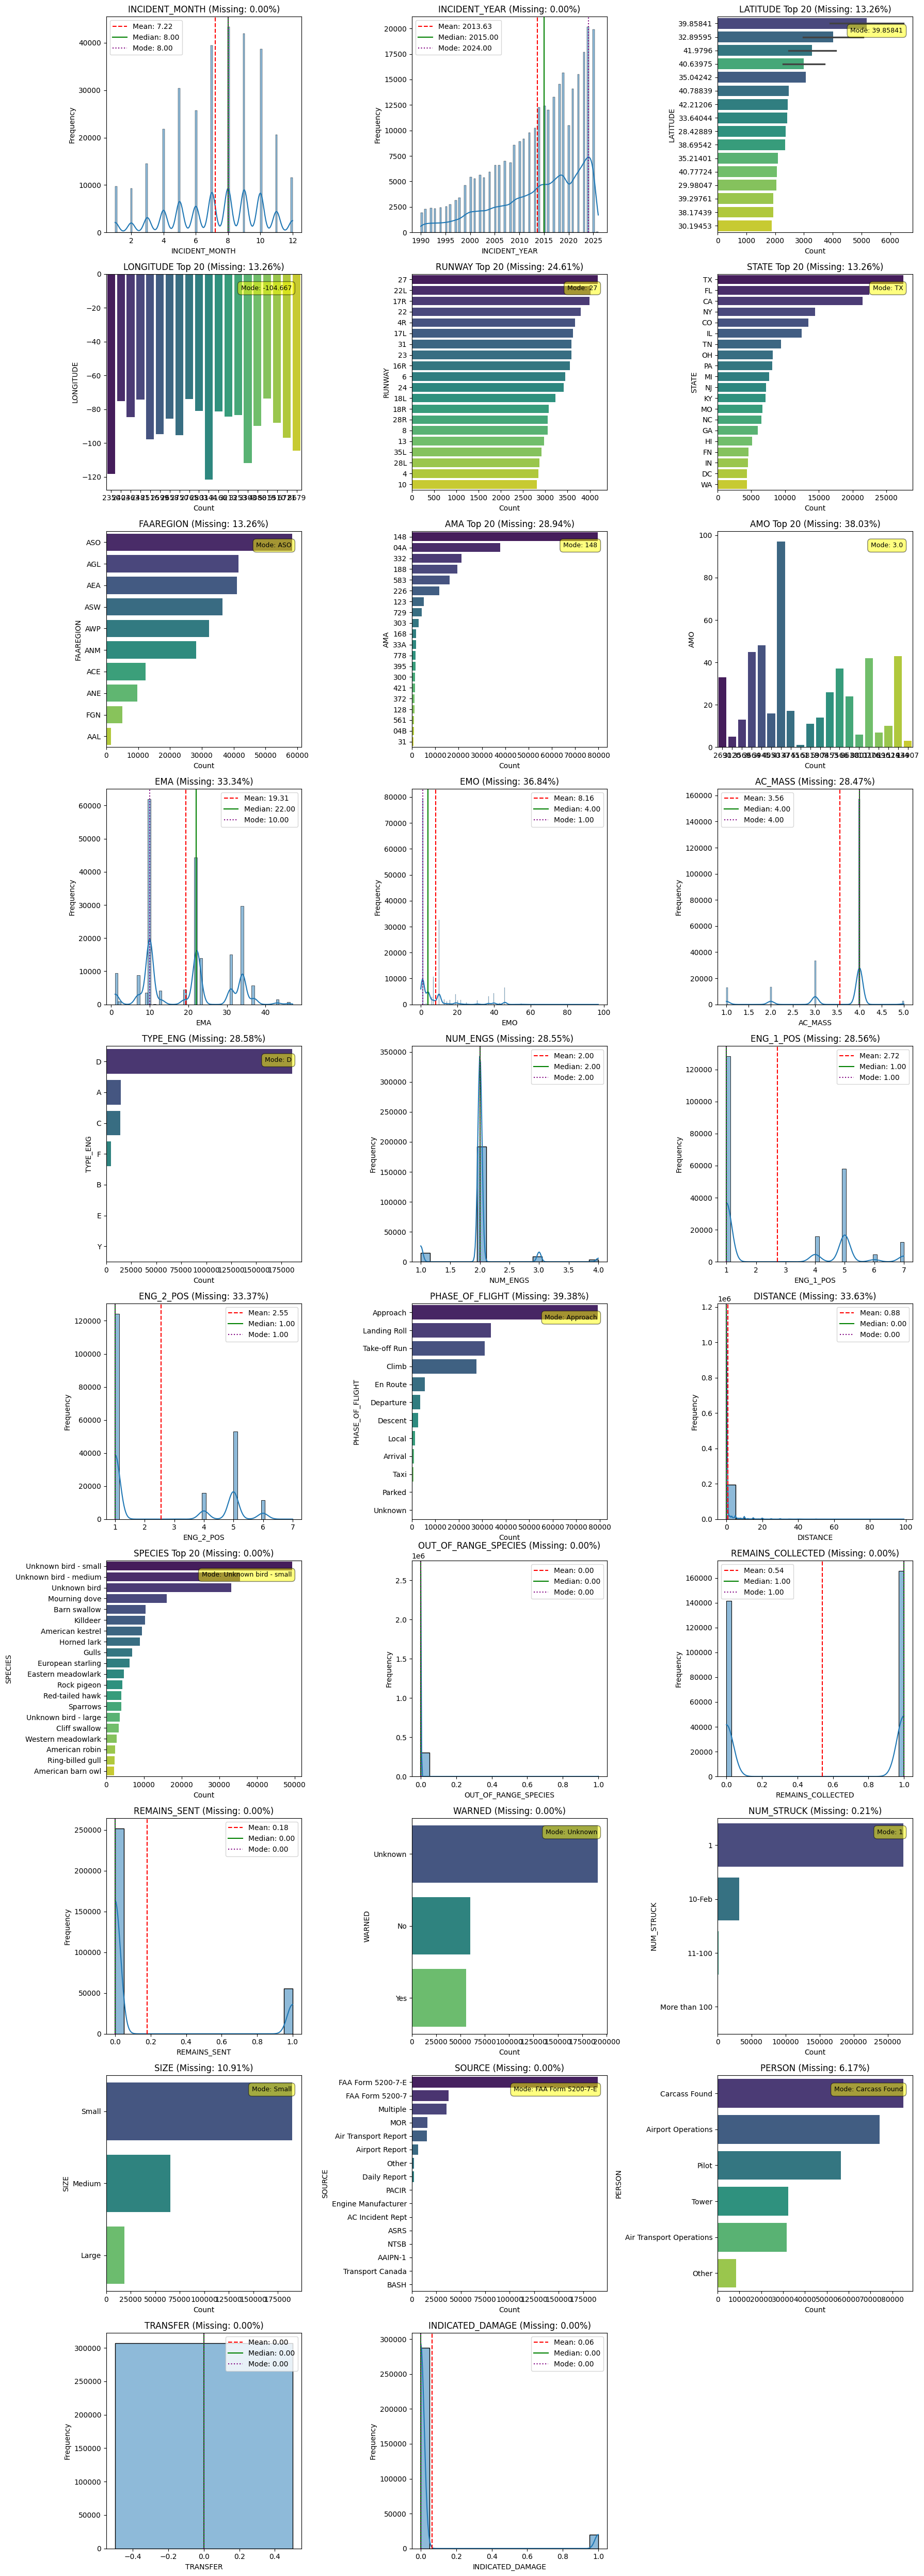

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Ensure pandas is imported for pd.api.types

# --- Start of added code to ensure df_cleaned and nan_percentages_cleaned are defined ---
# This block is added to handle potential NameErrors if prior cells defining
# df_cleaned and nan_percentages_cleaned were not executed.

# Ensure 'df' is available, reloading if necessary (assuming train.csv is present)
if 'df' not in globals():
    print("Warning: 'df' not found in global scope. Attempting to load 'train.csv' and create 'df'.")
    data = pd.read_csv('train.csv', skipinitialspace=True)
    df = pd.DataFrame(data)

# Ensure initial 'nan_percentages' (for original df) is available
if 'nan_percentages' not in globals():
    print("Warning: 'nan_percentages' not found. Re-calculating for original 'df'.")
    nan_percentages = (df.isnull().sum() / len(df)) * 100

# Ensure 'df_cleaned' is available. If not, re-create based on prior cleaning steps.
if 'df_cleaned' not in globals():
    print("Warning: 'df_cleaned' not found. Re-creating based on prior steps.")
    # Step from cell 400b964c: dropping columns with >40% NaNs
    columns_to_drop_initial = nan_percentages[nan_percentages > 40].index
    df_cleaned = df.drop(columns=columns_to_drop_initial.tolist(), errors='ignore')
    # Step from cell ePvUZAU-QUaS: further dropping specific categorical columns
    df_cleaned = df_cleaned.drop(columns=['AC_CLASS', 'AIRPORT', 'AIRCRAFT', 'OPERATOR', 'OPID'], errors='ignore')

# Ensure 'nan_percentages_cleaned' is available. If not, re-calculate.
if 'nan_percentages_cleaned' not in globals():
    print("Warning: 'nan_percentages_cleaned' not found. Re-calculating for 'df_cleaned'.")
    nan_percentages_cleaned = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100
# --- End of added code ---


# Columns to exclude from plotting due to high cardinality or type (like dates/IDs)
# These were identified and/or dropped in earlier steps for df_backfill,
# but for df_cleaned, they are still present and might cause cluttered plots.
exclude_from_plotting = [
    'INDEX_NR', 'INCIDENT_DATE', 'AIRPORT_ID', 'REG', 'SPECIES_ID',
    'REMARKS', 'COMMENTS', 'LUPDATE'
]

# Get all columns from df_cleaned that are not in the exclude list
columns_to_process = [col for col in df_cleaned.columns if col not in exclude_from_plotting]

# Determine grid size for subplots
n_cols = 3
n_rows = (len(columns_to_process) + n_cols - 1) // n_cols

# Create a figure for plotting
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
# Flatten axes for easy iteration, in case n_rows or n_cols is 1
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

plot_idx = 0
for col in columns_to_process:
    ax = axes[plot_idx]

    # Get missing percentage for the current column
    missing_percent = nan_percentages_cleaned.get(col, 0)

    # Check if the column is numerical
    if pd.api.types.is_numeric_dtype(df_cleaned[col]):
        col_mean = df_cleaned[col].mean()
        col_median = df_cleaned[col].median()
        col_mode = df_cleaned[col].mode().tolist()

        sns.histplot(df_cleaned[col].dropna(), kde=True, ax=ax)
        ax.set_title(f'{col} (Missing: {missing_percent:.2f}%)')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')

        # Add mean, median, mode to the plot for numerical columns
        ax.axvline(col_mean, color='r', linestyle='--', label=f'Mean: {col_mean:.2f}')
        ax.axvline(col_median, color='g', linestyle='-', label=f'Median: {col_median:.2f}')
        # Only plot mode if it's a single value, multiple modes can clutter
        if len(col_mode) == 1:
            ax.axvline(col_mode[0], color='purple', linestyle=':', label=f'Mode: {col_mode[0]:.2f}')
        ax.legend()

    else: # Categorical or object type
        col_mode = df_cleaned[col].mode().tolist()

        # Handle high cardinality for plotting
        if df_cleaned[col].nunique() > 20: # Limit to top 20 for readability
            data_to_plot = df_cleaned[col].value_counts().head(20)
            sns.barplot(x=data_to_plot.values, y=data_to_plot.index, ax=ax, palette='viridis')
            ax.set_title(f'{col} Top 20 (Missing: {missing_percent:.2f}%)')
        else:
            data_to_plot = df_cleaned[col].value_counts()
            sns.barplot(x=data_to_plot.values, y=data_to_plot.index, ax=ax, palette='viridis')
            ax.set_title(f'{col} (Missing: {missing_percent:.2f}%)')
        ax.set_xlabel('Count')
        ax.set_ylabel(col)

        # Add mode to the plot for categorical columns
        if col_mode:
            mode_str = ", ".join([str(m) for m in col_mode])
            ax.text(0.95, 0.95, f'Mode: {mode_str}', transform=ax.transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plot_idx += 1

# Remove any unused subplots
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Removed printing stats to console as they are now on plots
# If you still need them printed, please let me know!

to impute the values, we are going to do.....
latitude, longitude: these are actually just the location of the state so we are going to DROP them 🗺

runway: we will print this one again with showing the 0's because we just read how it works lol

state: another distribution showing which state hurts the most

ama: another distribution showing which state hurts the most

faarregion: we are going to check where the incident was, and then map that airpot to a state and then fill in the state.

type_eng; fill in with d because it is the most frequent

num_engs: fill in with all 2's because literally the mean median mode are all 2.

eng1,eng2,: backfill to preserve the distirbition


phase of flight: backfull it to keep distirbution

distance: use the mean

remains sent: this does not add beneficial information, we are dropping

warned: the yes and no are literally exactly the same so the unknown adds nothing so we drop it.

num_struck fill it in with all ones because thats is the overwhelimg mode and mean

size; backfill to perseve the distribution

sourece: does't matter who really wrote it so we will drop it

person - backfill it to keep distribution yay ⛹





In [ ]:
df_backfilled = df_cleaned.copy()

bfill_ffill_cols = ['ENG_1_POS', 'ENG_2_POS', 'PHASE_OF_FLIGHT', 'SIZE', 'PERSON']

print("Applying backfill and forwardfill to the following columns:")
for col in bfill_ffill_cols:
    if col in df_backfilled.columns:
        print(f"- {col}")
        df_backfilled[col] = df_backfilled[col].bfill()
        df_backfilled[col] = df_backfilled[col].ffill() # Ensure all NaNs are handled
    else:
        print(f"Warning: Column '{col}' not found in df_backfilled.")

print("\nMissing values percentages for df_backfilled after backfill/forwardfill:")
nan_percentages_backfilled = (df_backfilled.isnull().sum() / len(df_backfilled)) * 100
print(nan_percentages_backfilled) # Changed to print all columns

if nan_percentages_backfilled[nan_percentages_backfilled > 0].empty:
    print("No missing values remaining in the backfilled columns or other columns handled by bfill/ffill.")
else:
    print("Note: Other columns not specified for backfill/forwardfill may still have missing values.")

Applying backfill and forwardfill to the following columns:
- ENG_1_POS
- ENG_2_POS
- PHASE_OF_FLIGHT
- SIZE
- PERSON

Missing values percentages for df_backfilled after backfill/forwardfill:
INDEX_NR                 0.000000
INCIDENT_DATE            0.000000
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
AIRPORT_ID               0.000000
LATITUDE                13.263971
LONGITUDE               13.264947
RUNWAY                  24.606254
STATE                   13.263971
FAAREGION               13.263971
REG                     38.733894
AMA                     28.939572
AMO                     38.027788
EMA                     33.342557
EMO                     36.843784
AC_MASS                 28.467533
TYPE_ENG                28.578218
NUM_ENGS                28.549245
ENG_1_POS                0.000000
ENG_2_POS                0.000000
PHASE_OF_FLIGHT          0.000000
DISTANCE                33.629687
SPECIES_ID               0.000000
SPECIES                  0

here are the new missing rates with the backfill applied. we are now goingto drop the columns that we belive are no longer helpful described above this.

In [ ]:
columns_to_drop_from_backfilled = [
    'LATITUDE', 'LONGITUDE', 'REMAINS_SENT', 'WARNED', 'SOURCE'
]

# Create a new DataFrame df_dropped by dropping the specified columns
df_dropped = df_backfilled.drop(columns=columns_to_drop_from_backfilled, errors='ignore')

print(f"Dropped columns from df_backfilled: {columns_to_drop_from_backfilled}")

Dropped columns from df_backfilled: ['LATITUDE', 'LONGITUDE', 'REMAINS_SENT', 'WARNED', 'SOURCE']


In [ ]:
df_imputed = df_dropped.copy()

# Drop columns as per instruction or general irrelevance for modeling
columns_to_drop_from_imputed = ['INDEX_NR', 'COMMENTS']
df_imputed = df_imputed.drop(columns=columns_to_drop_from_imputed, errors='ignore')

# Impute TYPE_ENG with 'D' (most frequent)
df_imputed['TYPE_ENG'].fillna('D', inplace=True)

# Impute NUM_ENGS with '2'
df_imputed['NUM_ENGS'].fillna('2', inplace=True)

# Impute NUM_STRUCK with '1'
df_imputed['NUM_STRUCK'].fillna('1', inplace=True)

# Impute DISTANCE with the mean
mean_distance = df_imputed['DISTANCE'].mean()
df_imputed['DISTANCE'].fillna(mean_distance, inplace=True)

# Impute STATE and FAAREGION using AIRPORT_ID maps
# (airport_state_map and airport_faaregion_map are from kernel state)
#df_imputed['STATE'] = df_imputed['STATE'].fillna(df_imputed['AIRPORT_ID'].map(airport_state_map))
#df_imputed['FAAREGION'] = df_imputed['FAAREGION'].fillna(df_imputed['AIRPORT_ID'].map(airport_faaregion_map))

# Fill any remaining NaNs in STATE and FAAREGION with their modes
#mode_state = df_imputed['STATE'].mode()[0]
#df_imputed['STATE'].fillna(mode_state, inplace=True)
#mode_faaregion = df_imputed['FAAREGION'].mode()[0]
#df_imputed['FAAREGION'].fillna(mode_faaregion, inplace=True)

# Impute other remaining categorical/discrete numerical columns with their modes
mode_runway = df_imputed['RUNWAY'].mode()[0]
df_imputed['RUNWAY'].fillna(mode_runway, inplace=True)

mode_ama = df_imputed['AMA'].mode()[0]
df_imputed['AMA'].fillna(mode_ama, inplace=True)

mode_reg = df_imputed['REG'].mode()[0]
df_imputed['REG'].fillna(mode_reg, inplace=True)

mode_amo = df_imputed['AMO'].mode()[0]
df_imputed['AMO'].fillna(mode_amo, inplace=True)

mode_ema = df_imputed['EMA'].mode()[0]
df_imputed['EMA'].fillna(mode_ema, inplace=True)

mode_emo = df_imputed['EMO'].mode()[0]
df_imputed['EMO'].fillna(mode_emo, inplace=True)

mode_ac_mass = df_imputed['AC_MASS'].mode()[0]
df_imputed['AC_MASS'].fillna(mode_ac_mass, inplace=True)

# Impute REMARKS with 'UNKNOWN'
#df_imputed['REMARKS'].fillna('UNKNOWN', inplace=True)

# Display missing values percentages for the newly imputed DataFrame
nan_percentages_imputed = (df_imputed.isnull().sum() / len(df_imputed)) * 100
print("\nMissing values percentages for df_imputed:")
print(nan_percentages_imputed[nan_percentages_imputed > 0])

# If no missing values remain, print a confirmation message
if nan_percentages_imputed[nan_percentages_imputed > 0].empty:
    print("\nAll missing values have been successfully imputed!")

/tmp/ipykernel_6664/4149483561.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed['TYPE_ENG'].fillna('D', inplace=True)
/tmp/ipykernel_6664/4149483561.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try


Missing values percentages for df_imputed:
STATE        13.263971
FAAREGION    13.263971
REMARKS      11.489755
dtype: float64


In [ ]:
nan_percentages_dropped = (df_imputed.isnull().sum() / len(df_imputed)) * 100
print("\nMissing values percentages for df_dropped:")
print(nan_percentages_dropped)


Missing values percentages for df_dropped:
INCIDENT_DATE            0.000000
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
AIRPORT_ID               0.000000
RUNWAY                   0.000000
STATE                   13.263971
FAAREGION               13.263971
REG                      0.000000
AMA                      0.000000
AMO                      0.000000
EMA                      0.000000
EMO                      0.000000
AC_MASS                  0.000000
TYPE_ENG                 0.000000
NUM_ENGS                 0.000000
ENG_1_POS                0.000000
ENG_2_POS                0.000000
PHASE_OF_FLIGHT          0.000000
DISTANCE                 0.000000
SPECIES_ID               0.000000
SPECIES                  0.000000
OUT_OF_RANGE_SPECIES     0.000000
REMARKS                 11.489755
REMAINS_COLLECTED        0.000000
NUM_STRUCK               0.000000
SIZE                     0.000000
PERSON                   0.000000
LUPDATE                  0.000000
TRAN

Here we tried doing anomaly detection using isolation forests, but we gave up on this attempt since our data is supervised (has a distinct damage/no damage label to check if prediction is correct), while anomaly detection is mainly used for unsupervised learning.

In [ ]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import numpy as np

def detect_anomalies_isolation_forest(df: pd.DataFrame, numerical_features: list, contamination: float = 0.01):
    """
    Detects anomalies in specified numerical columns using the Isolation Forest algorithm.

    Args:
        df (pd.DataFrame): The input DataFrame.
        numerical_features (list): A list of numerical column names to process.
        contamination (float): The proportion of outliers in the data set. Default is 0.01.

    Returns:
        pd.DataFrame: The DataFrame with an 'anomaly' column (-1 for anomalies, 1 for normal).
        IsolationForest: The trained Isolation Forest model.
    """
    df_copy = df.copy()

    # Select only the numerical features for anomaly detection
    # Ensure only numerical columns that exist in the DataFrame are used.
    features_for_if = [f for f in numerical_features if f in df_copy.columns and pd.api.types.is_numeric_dtype(df_copy[f])]
    if not features_for_if:
        print("No numerical features found for Isolation Forest. Please check `numerical_features` list.")
        return df_copy, None

    X = df_copy[features_for_if].dropna() # Drop rows with NaNs in these features for IF

    # Initialize and train the Isolation Forest model
    # random_state for reproducibility
    model = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
    model.fit(X)

    # Predict anomalies. -1 for outliers and 1 for inliers.
    df_copy['anomaly'] = np.nan # Initialize 'anomaly' column with NaN
    df_copy.loc[X.index, 'anomaly'] = model.predict(X)

    print(f"Isolation Forest detected {np.sum(df_copy['anomaly'] == -1)} anomalies out of {len(X)} records.")
    print(f"Anomaly percentage: {np.sum(df_copy['anomaly'] == -1) / len(X) * 100:.2f}%")

    return df_copy, model

# Identify numerical features, excluding high-cardinality IDs and specific flags
# This list is based on the output of cell 770aab35 from the previous conversation.
exclude_cols = ['INDICATED_DAMAGE', 'TRANSFER', 'INCIDENT_YEAR', 'OUT_OF_RANGE_SPECIES', 'INDEX_NR', 'INCIDENT_MONTH']
numerical_features = [
    col for col in df_imputed.select_dtypes(include=['number']).columns
    if col not in exclude_cols
]

print("Applying Isolation Forest for anomaly detection on numerical features in df_imputed...")
df_anomalies, isolation_forest_model = detect_anomalies_isolation_forest(df_imputed, numerical_features, contamination=0.01)

if isolation_forest_model is not None:
    # Display some rows with anomalies
    print("\nFirst 10 rows identified as anomalies:")
    display(df_anomalies[df_anomalies['anomaly'] == -1].head(10))

    # You can also investigate the anomaly scores
    # Ensure to use the same features for decision_function as used for fitting
    features_for_if_score = [f for f in numerical_features if f in df_anomalies.columns and pd.api.types.is_numeric_dtype(df_anomalies[f])]
    X_for_scores = df_anomalies[features_for_if_score].dropna()

    df_anomalies['anomaly_score'] = np.nan
    df_anomalies.loc[X_for_scores.index, 'anomaly_score'] = isolation_forest_model.decision_function(X_for_scores)

    print("\nAnomalies with their scores (lower score indicates higher anomaly likelihood):")
    display(df_anomalies[df_anomalies['anomaly'] == -1].sort_values(by='anomaly_score').head())

Applying Isolation Forest for anomaly detection on numerical features in df_imputed...
Isolation Forest detected 3070 anomalies out of 307178 records.
Anomaly percentage: 1.00%

First 10 rows identified as anomalies:


,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,AIRPORT_ID,RUNWAY,STATE,FAAREGION,REG,AMA,AMO,...,OUT_OF_RANGE_SPECIES,REMARKS,REMAINS_COLLECTED,NUM_STRUCK,SIZE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE,anomaly
126,6/30/19,6,2019,KBKL,24R,OH,AGL,N62GW,729,26.0,...,0,OWNER/OPERATOR Goshen Wings,1,1,Small,Airport Operations,12/17/19,0,0,-1.0
186,2/25/08,2,2008,KSJT,18,TX,ASW,N912NA,148,3.0,...,0,"ID BY SMITHSONIAN,, FAA 2352 A & B. MULTIPLE B...",1,10-Feb,Large,Airport Operations,1/9/26,0,1,-1.0
577,10/16/98,10,1998,KEWR,27,NJ,AEA,N477HA,148,94.0,...,0,ALT 4300MSL NOT AGL. This would be 3500 AGL...,0,10-Feb,Small,Air Transport Operations,4/29/20,0,0,-1.0
638,3/7/09,3,2009,KTEB,24,NJ,AEA,N5194Y,226,3.0,...,0,NaN,1,1,Large,Tower,6/25/09,0,0,-1.0
675,7/15/11,7,2011,KCCR,19L,CA,AWP,N6371B,123,8.0,...,0,NaN,1,1,Small,Airport Operations,8/25/11,0,0,-1.0
740,4/30/22,4,2022,KMEM,18R,TN,ASO,N590FE,583,39.0,...,0,NaN,0,1,Medium,Pilot,5/23/22,0,0,-1.0
742,10/28/14,10,2014,ZZZZ,27,NaN,NaN,G-CIVS,148,34.0,...,0,ID BY SMITHSONIAN. MX GAVE ALL INFO. RT WING. ...,1,1,Small,Airport Operations,4/14/15,0,0,-1.0
804,6/13/14,6,2014,KMWA,29,IL,AGL,N747WS,226,33.0,...,0,4-5 INCH SPLATTER ON RT WINDSHLD.,0,1,Medium,Pilot,10/23/14,0,0,-1.0
957,6/4/13,6,2013,KSTL,12R,MO,ACE,N4630N,226,33.0,...,0,MAY BE A SWALLOW.,0,1,Small,Pilot,8/7/13,0,0,-1.0
972,10/2/08,10,2008,KSAT,12R,TX,ASW,N437UP,148,26.0,...,0,"EVENT 20147. SAW 12 BIRDS, HIT 2. RADOME AND F...",0,10-Feb,Small,Air Transport Operations,2/25/09,0,0,-1.0



Anomalies with their scores (lower score indicates higher anomaly likelihood):


,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,AIRPORT_ID,RUNWAY,STATE,FAAREGION,REG,AMA,AMO,...,REMARKS,REMAINS_COLLECTED,NUM_STRUCK,SIZE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE,anomaly,anomaly_score
139536,10/7/09,10,2009,KLAX,27,CA,AWP,VH-OJE,148,34.0,...,"ID BY SMITHSONIAN, FAA 3734. WHOLE FEATHER AND...",1,1,Small,Air Transport Operations,1/18/23,0,1,-1.0,-0.098168
298462,9/17/24,9,2024,KATL,26R,GA,ASO,N568DZ,04A,3.0,...,Delta Maintenance advised ATL Operations of an...,1,1,Small,Pilot,1/23/25,0,0,-1.0,-0.088551
253436,10/25/09,10,2009,KTEB,6,NJ,AEA,N103KC,729,23.0,...,"(DATA ENTRY NOTE: NO ID, ASSUME REMAINS NOT RE...",1,1,Small,Airport Operations,6/29/10,0,0,-1.0,-0.080278
146272,4/14/13,4,2013,KTEB,6,NJ,AEA,N300JA,421,4.0,...,ID BY SMITHSONIAN. A/C WAS TAKEN OUT OF SERVIC...,1,1,Small,Airport Operations,5/23/13,0,1,-1.0,-0.079276
33579,11/26/17,11,2017,KTEB,24,NJ,AEA,N445BJ,421,4.0,...,En route at 3000 feet and 250 kts.I see a floc...,1,10-Feb,Large,Pilot,4/12/22,0,1,-1.0,-0.079276


Here we tried various permutations of the above logic, tweaking some details to see what works better.

In [ ]:
# OLD METHOD FROM 04/16, all preproccessing is occuring here makes it more
# readable
def old_apply_all_preprocessing(df_input_raw: pd.DataFrame) -> pd.DataFrame:
   df_temp = df_input_raw.copy()

   # --- Step 1a: Drop columns with >40% NaN (computed from input, mirrors dynamic drop) ---
   nan_percentages = (df_temp.isnull().sum() / len(df_temp)) * 100
   high_nan_cols = nan_percentages[nan_percentages > 40].index.tolist()
   df_temp.drop(columns=high_nan_cols, errors='ignore', inplace=True)

   # --- Step 1b: Drop second batch of specific columns (mirrors your manual drops) ---
   second_drop_cols = [
       'LATITUDE', 'LONGITUDE', 'REMAINS_SENT', 'WARNED', 'SOURCE',
       'INDEX_NR', 'COMMENTS'
   ]
   df_temp.drop(columns=[col for col in second_drop_cols if col in df_temp.columns], errors='ignore', inplace=True)

   # --- Step 2: Backfill/Forwardfill ---
   bfill_ffill_cols = ['ENG_1_POS', 'ENG_2_POS', 'PHASE_OF_FLIGHT', 'SIZE', 'PERSON']
   for col in bfill_ffill_cols:
       if col in df_temp.columns:
           df_temp[col] = df_temp[col].bfill().ffill()
   # --- Step 3: Specific Imputations ---

   # Impute TYPE_ENG with 'D' (most frequent)
   if 'TYPE_ENG' in df_temp.columns:
       df_temp['TYPE_ENG'].fillna('D', inplace=True)

   # Impute NUM_ENGS with '2' (string, mirrors your manual version)
   if 'NUM_ENGS' in df_temp.columns:
       df_temp['NUM_ENGS'].fillna('2', inplace=True)

   # Impute NUM_STRUCK with '1' (string, mirrors your manual version)
   if 'NUM_STRUCK' in df_temp.columns:
       df_temp['NUM_STRUCK'].fillna('1', inplace=True)

   # Impute DISTANCE with training mean (avoids leakage on test set)
   if 'DISTANCE' in df_temp.columns:
       df_temp['DISTANCE'].fillna(train_distance_mean, inplace=True)

   # Impute REG with mode (kept, not dropped — mirrors your manual version)
   if 'REG' in df_temp.columns:
       mode_reg = df_temp['REG'].mode()[0]
       df_temp['REG'].fillna(mode_reg, inplace=True)

   # Impute remaining columns with their modes
   mode_impute_cols = ['RUNWAY', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_MASS']
   for col in mode_impute_cols:
       if col in df_temp.columns and df_temp[col].isnull().any():
           mode_val = df_temp[col].mode()[0]
           df_temp[col].fillna(mode_val, inplace=True)

   if 'STATE' in df_temp.columns and df_temp['STATE'].isnull().any():
       df_temp['STATE'] = df_temp['STATE'].bfill().ffill()

   if 'FAAREGION' in df_temp.columns and df_temp['FAAREGION'].isnull().any():
       df_temp['FAAREGION'] = df_temp['FAAREGION'].bfill().ffill()
   print("\nFinal columns in processed DataFrame:")
   print(df_temp.columns.tolist())


   return df_temp


In [ ]:
# SERGIO VERSION IVE BEEN MESSING AROUND WITH
def apply_all_preprocessing(df_input_raw: pd.DataFrame) -> pd.DataFrame:
    df_temp = df_input_raw.copy()

    # --- Step 1a: Drop columns with >40% NaN (computed from input, mirrors dynamic drop) ---
    nan_percentages = (df_temp.isnull().sum() / len(df_temp)) * 100
    high_nan_cols = nan_percentages[nan_percentages > 60].index.tolist()
    df_temp.drop(columns=high_nan_cols, errors='ignore', inplace=True)

    # --- Step 1b: Drop second batch of specific columns (mirrors your manual drops) ---
    second_drop_cols = [
        'LATITUDE', 'LONGITUDE', 'REMAINS_SENT', 'WARNED', 'SOURCE',
        'INDEX_NR', 'COMMENTS', 'INCIDENT_DATE', 'AIRPORT',
        'OPERATOR', 'AIRCRAFT', 'SPECIES', 'EMA', 'EMO',
        'LUPDATE', 'TRANSFER', 'REG', 'OUT_OF_RANGE_SPECIES', 'REMARKS', 'FLT', 'AMA', 'AMO', 'RUNWAY',
        'AC_CLASS', 'ENG_2_POS'
    ]
    df_temp.drop(columns=[col for col in second_drop_cols if col in df_temp.columns], errors='ignore', inplace=True)

    # --- Step 2: Backfill/Forwardfill ---
    for col in ['ENG_1_POS', 'PHASE_OF_FLIGHT', 'SIZE', 'PERSON', 'SPECIES_ID']:
      if col in df_temp.columns:
          mode_val = df_temp[col].mode()[0]
          df_temp[col].fillna(mode_val, inplace=True)

    # --- Step 3: Specific Imputations ---

    # Impute TYPE_ENG with 'D' (most frequent)
    if 'TYPE_ENG' in df_temp.columns:
        df_temp['TYPE_ENG'].fillna('D', inplace=True)

    # Impute NUM_ENGS with '2' (string, mirrors your manual version)
    if 'NUM_ENGS' in df_temp.columns:
        df_temp['NUM_ENGS'].fillna('2', inplace=True)

    # Impute NUM_STRUCK with '1' (string, mirrors your manual version)
    if 'NUM_STRUCK' in df_temp.columns:
        df_temp['NUM_STRUCK'].fillna('1', inplace=True)

    # Impute DISTANCE with training mean (avoids leakage on test set)
    if 'DISTANCE' in df_temp.columns:
        df_temp['DISTANCE'].fillna(train_distance_mean, inplace=True)

    # Impute remaining columns with their modes
    mode_impute_cols = ['AMA', 'AMO', 'AC_MASS', 'TIME']
    for col in mode_impute_cols:
        if col in df_temp.columns and df_temp[col].isnull().any():
            mode_val = df_temp[col].mode()[0]
            df_temp[col].fillna(mode_val, inplace=True)

    if 'STATE' in df_temp.columns and df_temp['STATE'].isnull().any():
        df_temp['STATE'] = df_temp['STATE'].bfill().ffill()

    if 'FAAREGION' in df_temp.columns and df_temp['FAAREGION'].isnull().any():
        df_temp['FAAREGION'] = df_temp['FAAREGION'].bfill().ffill()

    # Speed proxy — high risk phases
    df_temp['is_high_risk_phase'] = df_temp['PHASE_OF_FLIGHT'].isin(
        ['Take-off Run', 'Landing Roll', 'Approach', 'Climb']
    ).astype(int)

    # Large bird flag
    df_temp['is_large_bird'] = (df_temp['SIZE'] == 'Large').astype(int)

    # Multiple birds struck
    df_temp['multi_strike'] = (pd.to_numeric(df_temp['NUM_STRUCK'], errors='coerce') > 1).astype(int)

    print(df_temp['INCIDENT_MONTH'].dtype)
    print(df_temp['INCIDENT_MONTH'].unique()[:5])

    if 'INCIDENT_MONTH' in df_temp.columns:
      df_temp['SEASON'] = df_temp['INCIDENT_MONTH'].map({
          12: 'Winter', 1: 'Winter', 2: 'Winter',
          3: 'Spring', 4: 'Spring', 5: 'Spring',
          6: 'Summer', 7: 'Summer', 8: 'Summer',
          9: 'Fall', 10: 'Fall', 11: 'Fall'
      })
    # TIME_OF_DAY: categorical, mode impute
    if 'TIME_OF_DAY' in df_temp.columns:
        df_temp['TIME_OF_DAY'].fillna(df_temp['TIME_OF_DAY'].mode()[0], inplace=True)

    # HEIGHT: numeric, median is safer than mean due to skew (most strikes near ground)
    if 'HEIGHT' in df_temp.columns:
        df_temp['HEIGHT'].fillna(df_temp['HEIGHT'].median(), inplace=True)

    # SKY: categorical, mode impute
    if 'SKY' in df_temp.columns:
        df_temp['SKY'].fillna(df_temp['SKY'].mode()[0], inplace=True)

    second_drop_cols = [
        'INCIDENT_MONTH', 'SIZE'
    ]
    df_temp.drop(columns=[col for col in second_drop_cols if col in df_temp.columns], errors='ignore', inplace=True)


    print("\nFinal columns in processed DataFrame:")
    print(df_temp.columns.tolist())

    return df_temp

Here we are trying the CatBoost model.

In [ ]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from catboost import CatBoostClassifier # run the cell above to install catboost guys
from sklearn.metrics import balanced_accuracy_score

# --- Load original df if not already loaded (for train/val split) ---
if 'df' not in globals():
    data = pd.read_csv('train.csv', skipinitialspace=True)
    df = pd.DataFrame(data)

# ── Split raw data BEFORE any preprocessing ─────
# Split the ORIGINAL df, then apply preprocessing separately to avoid leakage
train_raw, val_raw = train_test_split(df, test_size=0.2, random_state=67)
train_distance_mean = pd.to_numeric(train_raw['DISTANCE'], errors='coerce').mean()

X_train = apply_all_preprocessing(train_raw.drop(columns=['INDICATED_DAMAGE'], errors='ignore'))
y_train = train_raw.loc[X_train.index, 'INDICATED_DAMAGE'].values

X_val = apply_all_preprocessing(val_raw.drop(columns=['INDICATED_DAMAGE'], errors='ignore'))
y_val = val_raw.loc[X_val.index, 'INDICATED_DAMAGE'].values

# ── Load test set and apply preprocessing ────────────────────
df_test_raw = pd.read_csv('test.csv', skipinitialspace=True)
test_index_nr = df_test_raw['INDEX_NR'].copy()
X_test = apply_all_preprocessing(df_test_raw)

# ── Align columns (Important as preprocessing might remove different columns if data is skewed) ───────────────────────
# Get all columns from X_train (which is the most comprehensive processed set)
final_cols = X_train.columns.tolist()

# Ensure X_val and X_test have the same columns in the same order as X_train
X_val = X_val.reindex(columns=final_cols, fill_value=0) # fill_value can be chosen based on context
X_test = X_test.reindex(columns=final_cols, fill_value=0) # fill_value can be chosen based on context

# ── Tell CatBoost which columns are categorical ─────
# After preprocessing, identify categorical columns again for CatBoost
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# CatBoost handles NaNs internally for categorical features, but ensure all are string type
# (apply_all_preprocessing should already handle this by filling with 'UNKNOWN' and converting to str)
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)


# ── Train CatBoost ──────────────
cat_classifier = CatBoostClassifier(
    iterations=1000,
    loss_function='Logloss',
    eval_metric='Accuracy',
    auto_class_weights='Balanced',
    random_seed=67,
    one_hot_max_size=255,
    verbose=100,
    cat_features=cat_features,
    bagging_temperature=0.43462717937065204,
    border_count=117,
    colsample_bylevel=0.9521871356061031,
    depth=5,
    l2_leaf_reg=6.428658848831819,
    learning_rate=0.08622121759478739,
    min_data_in_leaf=10,
    random_strength=1.4130691409658205
)

cat_classifier.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

# ── Evaluate ───────────────────────
#threshold = 0.64775 # Use the same threshold as before
threshold = 0.5
y_val_proba = cat_classifier.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba >= threshold).astype(int)

print("CatBoost Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

bal_acc = balanced_accuracy_score(y_val, y_val_pred)
print("Balanced Accuracy:", bal_acc)

# ── Predict on test set for submission ─────────────
test_proba = cat_classifier.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= threshold).astype(int)

submission = pd.DataFrame({'INDEX_NR': test_index_nr.loc[X_test.index], 'INDICATED_DAMAGE': test_pred})
submission.to_csv('submission_5.csv', index=False)
print("Saved submission_5.csv")

/tmp/ipykernel_17541/2947759875.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_temp[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_17541/2947759875.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

int64
[11  6 10  5  8]

Final columns in processed DataFrame:
['INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'STATE', 'FAAREGION', 'OPID', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'DISTANCE', 'SKY', 'SPECIES_ID', 'REMAINS_COLLECTED', 'NUM_STRUCK', 'PERSON', 'is_high_risk_phase', 'is_large_bird', 'multi_strike', 'SEASON']


/tmp/ipykernel_17541/2947759875.py:80: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_temp['TIME_OF_DAY'].fillna(df_temp['TIME_OF_DAY'].mode()[0], inplace=True)
/tmp/ipykernel_17541/2947759875.py:84: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

int64
[10  3  5  8  7]

Final columns in processed DataFrame:
['INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'STATE', 'FAAREGION', 'OPID', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'DISTANCE', 'SKY', 'SPECIES_ID', 'REMAINS_COLLECTED', 'NUM_STRUCK', 'PERSON', 'is_high_risk_phase', 'is_large_bird', 'multi_strike', 'SEASON']


/tmp/ipykernel_17541/3627061609.py:27: DtypeWarning: Columns (8,9,20,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test_raw = pd.read_csv('test.csv', skipinitialspace=True)
/tmp/ipykernel_17541/2947759875.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_temp[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_17541/2947759875.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change

int64
[ 7  6 11 10  4]

Final columns in processed DataFrame:
['INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'STATE', 'FAAREGION', 'OPID', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'DISTANCE', 'SKY', 'SPECIES_ID', 'REMAINS_COLLECTED', 'NUM_STRUCK', 'PERSON', 'is_high_risk_phase', 'is_large_bird', 'multi_strike', 'SEASON']
0:	learn: 0.7865700	test: 0.7869006	best: 0.7869006 (0)	total: 256ms	remaining: 4m 16s
100:	learn: 0.8162142	test: 0.8110505	best: 0.8110505 (100)	total: 34.5s	remaining: 5m 6s
200:	learn: 0.8248041	test: 0.8188081	best: 0.8190613 (197)	total: 54.3s	remaining: 3m 35s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8200085638
bestIteration = 237

Shrink model to first 238 iterations.
CatBoost Validation Accuracy: 0.8235236669053975
              precision    recall  f1-score   support

           0       0.98      0.82      0.90     57484
           1       0.24      0.82      0.37      3952

    accuracy  

In [ ]:
missing_state_mask = df['STATE'].isnull()
print(df[missing_state_mask]['AIRPORT_ID'].unique())

# Task
Identify the numerical features in the `df_imputed` DataFrame, excluding high-cardinality IDs or categorical-encoded variables. For each identified feature, generate a distribution plot using `seaborn` and `matplotlib` that combines a Box Plot to detect outliers and a Histogram with a KDE overlay to visualize the density. Ensure the plots are displayed in a clear grid layout with grid lines enabled to assist in identifying specific outlier value ranges.

## Identify Numerical Features

### Subtask:
Filter the `df_imputed` DataFrame to isolate continuous numerical features, excluding any high-cardinality identifiers or columns that function as categorical codes.


**Reasoning**:
I will inspect the data types and unique value counts of df_imputed to identify continuous numerical features, then create a filtered list of relevant numeric columns for further analysis while excluding categorical flags and IDs.



In [ ]:
import pandas as pd

# 1. Inspect data types and unique counts
print("Data Types:")
print(df_imputed.dtypes)
print("\nUnique Values Count:")
print(df_imputed.nunique())

# 2 & 3. Identify numerical features while excluding IDs, binary flags, and date components
# Based on previous inspection, we exclude INDICATED_DAMAGE (target), TRANSFER (binary),
# INCIDENT_YEAR (date component), and OUT_OF_RANGE_SPECIES (binary/categorical flag).
exclude_cols = ['INDICATED_DAMAGE', 'TRANSFER', 'INCIDENT_YEAR', 'OUT_OF_RANGE_SPECIES', 'INDEX_NR', 'INCIDENT_MONTH']

numerical_features = [
    col for col in df_imputed.select_dtypes(include=['number']).columns
    if col not in exclude_cols
]

# 4. Filter list for continuous/multi-valued discrete variables
# We verify relevant columns like 'DISTANCE', 'NUM_ENGS', or 'HEIGHT' (if present after imputation)
print(f"\nIdentified Numerical Features for Analysis: {numerical_features}")

Data Types:
INCIDENT_DATE            object
INCIDENT_MONTH            int64
INCIDENT_YEAR             int64
AIRPORT_ID               object
RUNWAY                   object
STATE                    object
FAAREGION                object
REG                      object
AMA                      object
AMO                      object
EMA                     float64
EMO                     float64
AC_MASS                 float64
TYPE_ENG                 object
NUM_ENGS                 object
ENG_1_POS               float64
ENG_2_POS               float64
PHASE_OF_FLIGHT          object
DISTANCE                float64
SPECIES_ID               object
SPECIES                  object
OUT_OF_RANGE_SPECIES      int64
REMARKS                  object
REMAINS_COLLECTED         int64
NUM_STRUCK               object
SIZE                     object
PERSON                   object
LUPDATE                  object
TRANSFER                  int64
INDICATED_DAMAGE          int64
dtype: object

Unique Values

# New Section WITH BETTER MODEL


Here we tried making a completely different model by using feature engineering and imputing missing values with default empty/UNKNOWN/mean/mode as we saw fit. We also put modifications to data & the model into a Pipeline.

In [ ]:
import pandas as pd
data = pd.read_csv('train.csv', skipinitialspace=True)
# make a DataFrame
dfNew = pd.DataFrame(data)
dfNew.head()

/tmp/ipykernel_6664/3329017540.py:2: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('train.csv', skipinitialspace=True)


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


This was us looking at correlation between the feature columns to the target feature for any direct relationships. However, we later realized that this only shows linear relationships, so if columns had nonlinear relationships to the target feature it would not be evident here.

In [ ]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

# Ensure dfNew is available. Reload if necessary.
# Based on the kernel state, dfNew is already loaded.
if 'dfNew' not in globals():
    print("Warning: 'dfNew' not found. Attempting to load 'train.csv' into dfNew.")
    data = pd.read_csv('train.csv', skipinitialspace=True)
    dfNew = pd.DataFrame(data)

df_corr_ready = dfNew.copy()

# Drop date-like columns that are hard to convert to meaningful numeric for direct correlation
# without complex feature engineering, and are not typically directly correlated as raw strings.
# 'INCIDENT_DATE' and 'LUPDATE'
df_corr_ready = df_corr_ready.drop(columns=['INCIDENT_DATE', 'LUPDATE'], errors='ignore')

# Separate numerical and categorical columns
numerical_cols = df_corr_ready.select_dtypes(include=np.number).columns
categorical_cols = df_corr_ready.select_dtypes(include='object').columns

# Handle missing values in numerical columns by imputing with the median
for col in numerical_cols:
    if df_corr_ready[col].isnull().any():
        df_corr_ready[col] = df_corr_ready[col].fillna(df_corr_ready[col].median())

# Ordinal encode categorical columns
# Fill NaNs with 'UNKNOWN' before encoding to ensure all values are strings for OrdinalEncoder
for col in categorical_cols:
    df_corr_ready[col] = df_corr_ready[col].fillna('UNKNOWN').astype(str)
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    # Reshape for OrdinalEncoder and assign back
    df_corr_ready[col] = oe.fit_transform(df_corr_ready[[col]])

# Ensure all columns are numeric (float) before correlation calculation
df_corr_ready = df_corr_ready.astype(float)

# Print total columns and records
print(f"Total columns in df_corr_ready: {df_corr_ready.shape[1]}")
print(f"Total records in df_corr_ready: {df_corr_ready.shape[0]}")

# Calculate the correlation matrix
correlation_matrix_full = df_corr_ready.corr()

if 'INDICATED_DAMAGE' in correlation_matrix_full.columns:
    # Get correlations with 'INDICATED_DAMAGE'
    damage_correlations = correlation_matrix_full['INDICATED_DAMAGE']

    # Sort by absolute magnitude (strength) of correlation
    damage_correlations_magnitude = damage_correlations.abs().sort_values(ascending=False)

    # Exclude self-correlation ('INDICATED_DAMAGE' with itself) and NaN values (e.g., from constant columns)
    damage_correlations_magnitude = damage_correlations_magnitude.drop('INDICATED_DAMAGE', errors='ignore').dropna()

    # Get the original correlation values for display, in the order of magnitude
    final_correlations = damage_correlations.loc[damage_correlations_magnitude.index]

    print("\n--- Correlation with INDICATED_DAMAGE (All Columns, Sorted by Absolute Magnitude) ---")
    print(final_correlations)
else:
    print("\n'INDICATED_DAMAGE' column not found in the processed DataFrame for correlation.")

Total columns in df_corr_ready: 53
Total records in df_corr_ready: 307178

--- Correlation with INDICATED_DAMAGE (All Columns, Sorted by Absolute Magnitude) ---
SIZE                   -0.268432
AC_MASS                -0.228270
TYPE_ENG               -0.205368
ENG_1_POS               0.177108
AC_CLASS               -0.153370
SPECIES_ID             -0.139793
INCIDENT_YEAR          -0.138649
OPERATOR               -0.134072
PHASE_OF_FLIGHT        -0.131629
AMO                    -0.128305
REG                    -0.123694
OPID                   -0.121161
REMAINS_COLLECTED      -0.118433
AMA                    -0.112025
HEIGHT                  0.110989
SKY                    -0.108429
ENROUTE_STATE          -0.107683
TIME_OF_DAY            -0.100696
NUM_SEEN               -0.099692
AIRCRAFT               -0.097393
NUM_ENGS               -0.081316
NUM_STRUCK              0.080337
RUNWAY                  0.075864
EMO                     0.075835
ENG_2_POS               0.070716
PERSON        

We throught about dropping columns that had zero correlation to indicuated damange but then my teammates talked about how the correlation could also not be linear so that woudn't be captured and if we dropped it, we may actually drop a good feature. Instead we are going to drop columns we know provide no value such as the ID or identifciation.

DROPPING VALUES...



index_nr - this is used for identification not needed

incident_date - there is 2 more columns with year and month so this is just redudant

time - dropping time because it is numerical so they
will place again weights on the time if its later

airport - there is a lot of cardinality so itll introduce a lot of complexity if we do a hot one encoding

airport_id - also has a lot of cardinality

latitude - lots of cardinality and serves the same purpose as state

longitude - lots of cardinality and serves the same purpose as the state

runway - we are dropping runway and transforming it details below

location - free text that displays where the plane is headed. model cannot put english to statistics

opid - uses as an identifier

operator - drop for now (looking into again and featuere enginere this)

reg - droppoing reg because this is just an identifier

flt - droppping flt because this is just an indentifier

AIRCRAFT - over 600 diffrent aircafts....

AMA - there is a lot of ama as well  which means lots of cardinality and since its numerical it requires

AMO - lots of cardinality and also numerical

EMA - lots of cardinality and also numerical

EMO - lots of cardinality and also numerical

ENG_2_POS - gave back a lower correlation than engine 1 and would rather only keep 1 engine

ENG_3_POS - not many have it in general

ENG_4_POS - not many have it in general

height - very similar to phase of flight just numerical

speed - missing 70% of data actually cannot impute

precipitation - missing 96% of data actually useless

BIRD_BAND_NUMBER - just identificaiton number

SPECIES_ID  - just identification mumber

species - we only need the size of the bird but all birds do matter in my heawrt

OUT_OF_RANGE_SPECIES - just a sad fact but not sure how it helps

REMARKS - just notes so we can't really digst it in a way due to cardinality

REMAINS_SENT  - remains collected is enough for this catergory type

NUM_SEEN - dropping this and chanign it to another feature due to the bad formatting

NUM_STRUCK - dropping this due to the bad data in it and also none or just 1

ENROUTE_STATE - missing 98% so not even worth it

PERSON - works as an identier not needed.

LUPDATE - works as an identier not needed

TRANSFER  - just a flag for an identier not needed








FEATURE ENGINEERING...



month- we are going to change this into a season by %4. this is because the number carry magnituyde and we do not want the model to assign it more to later months.


 time_of_day - this is already split into 4 but we belive it is better if we dicate dya or night to reduce complexity

runway - change this to actually be aboolean of it was in a runway or not because the original one has too much cardinality


In [ ]:
# Dropping these identifier columns before pipeline
drop_before = [
    "INDEX_NR",
    "LOCATION",
    "OPID",
    "REG",
    "COMMENTS",
    "SPECIES_ID",
    "BIRD_BAND_NUMBER",
    "REMARKS",
    "PERSON",
    "LUPDATE",
    "TRANSFER",
    "FLT"
]

# drop them from the dataset
dfNew = dfNew.drop(columns=drop_before, errors="ignore")

# check remaining columns
print("New shape:", dfNew.shape)
print("Remaining columns:")
print(dfNew.columns.tolist())

New shape: (307178, 43)
Remaining columns:
['INCIDENT_DATE', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'AIRPORT', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'OPERATOR', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'SPECIES', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'SIZE', 'ENROUTE_STATE', 'SOURCE', 'INDICATED_DAMAGE']


In [ ]:
import pandas as pd

results = []

total_rows = len(dfNew)
num_columns = dfNew.shape[1]

print(f"\nTotal Columns in dfNew: {num_columns}")

# max missing per row
max_missing = int(dfNew.isnull().sum(axis=1).max())
print(f"Maximum missing columns in any row: {max_missing}\n")

for k in range(max_missing, -1, -1):

    mask = dfNew.isnull().sum(axis=1) <= k
    df_subset = dfNew[mask]

    rows_kept = len(df_subset)
    percent_kept = rows_kept / total_rows if total_rows > 0 else 0

    # average missing columns per row (for kept data)
    avg_missing_cols = df_subset.isnull().sum(axis=1).mean() if rows_kept > 0 else 0

    # counts
    count_0 = (df_subset["INDICATED_DAMAGE"] == 0).sum()
    count_1 = (df_subset["INDICATED_DAMAGE"] == 1).sum()

    # percentages
    pct_0 = count_0 / rows_kept if rows_kept > 0 else 0
    pct_1 = count_1 / rows_kept if rows_kept > 0 else 0

    results.append([
        k,
        rows_kept,
        percent_kept,
        avg_missing_cols,
        count_0,
        pct_0,
        count_1,
        pct_1
    ])

results_df = pd.DataFrame(results, columns=[
    "Max Missing",
    "Rows Kept",
    "% Kept",
    "Avg Missing Cols",
    "Count (0)",
    "% (0)",
    "Count (1)",
    "% (1)"
])

pd.set_option("display.max_rows", None)
pd.set_option("display.width", 140)

print(results_df.to_string(index=False, formatters={
    "% Kept": "{:.2%}".format,
    "% (0)": "{:.2%}".format,
    "% (1)": "{:.2%}".format,
    "Avg Missing Cols": "{:.2f}".format
}))


Total Columns in dfNew: 55
Maximum missing columns in any row: 33

 Max Missing  Rows Kept  % Kept Avg Missing Cols  Count (0)   % (0)  Count (1)  % (1)
          33     307178 100.00%            15.21     287651  93.64%      19527  6.36%
          32     307177 100.00%            15.21     287651  93.64%      19526  6.36%
          31     307164 100.00%            15.21     287638  93.64%      19526  6.36%
          30     307099  99.97%            15.20     287575  93.64%      19524  6.36%
          29     307006  99.94%            15.20     287484  93.64%      19522  6.36%
          28     306946  99.92%            15.20     287426  93.64%      19520  6.36%
          27     306818  99.88%            15.19     287302  93.64%      19516  6.36%
          26     304554  99.15%            15.10     285046  93.59%      19508  6.41%
          25     284339  92.56%            14.33     264843  93.14%      19496  6.86%
          24     223114  72.63%            11.40     203633  91.27%     

based on the results, we are going to drop recoreds that have more than 12 missing columns because they are missing too much data for it to be a reliable records. If we go below that, we lose 70k records of 0's which would make the model believe there is more planes that result in indicated_damange than in reality.

In [ ]:
# compute missing columns per row
row_missing_count = dfNew.isnull().sum(axis=1)

# apply cutoff (k = 23)
dfDropped = dfNew[row_missing_count <= 23].copy()

# sanity checks
print("Original shape:", dfNew.shape)
print("New shape:", dfDropped.shape)
print("Rows removed:", dfNew.shape[0] - dfDropped.shape[0])

# check class distribution
print("\nNew class distribution:")
print(dfDropped["INDICATED_DAMAGE"].value_counts(normalize=True))

Original shape: (307178, 43)
New shape: (306917, 43)
Rows removed: 261

New class distribution:
INDICATED_DAMAGE
0    0.936419
1    0.063581
Name: proportion, dtype: float64


based on evrything we decided, here is the piepoine so that there is no leakage and so that we can just test the models one by one using the same sequence we have already decided on above. Here we just have the linear regression as a place holder so that we are able to see what it could look like.

We are feature engineering new columns out of the existing ones (for example Months are categorized into Seasons to reduce dimensionality and still keep the major trend between the months.) We are also imputing missing values with either a default empty value or by the mean/mode where we feel is appropriate.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pandas as pd

pipeline = Pipeline([

    ("feature_engineering", FunctionTransformer(
        lambda X: X.assign(
            SEASON=X["INCIDENT_MONTH"].map({
                12: "Winter", 1: "Winter", 2: "Winter",
                3: "Spring", 4: "Spring", 5: "Spring",
                6: "Summer", 7: "Summer", 8: "Summer",
                9: "Fall", 10: "Fall", 11: "Fall"
            }),

            DAY_NIGHT=X["TIME_OF_DAY"].replace({
                "Day": "Day",
                "Night": "NotDay",
                "Dawn": "NotDay",
                "Dusk": "NotDay"
            }),

            HAS_RUNWAY_INFO=X["RUNWAY"].notna().astype(int)
        ),
        validate=False
    )),

    ("drop_high_cardinality", FunctionTransformer(
        lambda X: X.drop(columns=[
            "AIRPORT", "AIRPORT_ID", "AIRCRAFT",
            "AMA", "AMO", "EMA", "EMO", "OPERATOR"
        ], errors="ignore"),
        validate=False
    )),

    ("drop_unrelated", FunctionTransformer(
        lambda X: X.drop(columns=[
            "INCIDENT_DATE", "TIME", "RUNWAY",
            "LOCATION", "LATITUDE", "LONGITUDE",
            "HEIGHT", "SPEED", "PRECIPITATION",
            "SPECIES", "OUT_OF_RANGE_SPECIES",
            "REMARKS", "REMAINS_SENT",
            "NUM_SEEN", "NUM_STRUCK",
            "ENROUTE_STATE", "ENG_3_POS",
            "ENG_4_POS", "ENG_2_POS",
            "INCIDENT_MONTH",
            "TIME_OF_DAY"
        ], errors="ignore"),
        validate=False
    )),

    ("impute_categorical", FunctionTransformer(
        lambda X: X.assign(
            AC_CLASS=X["AC_CLASS"].fillna("A"),
            TYPE_ENG=X["TYPE_ENG"].fillna("D"),
            PHASE_OF_FLIGHT=X["PHASE_OF_FLIGHT"].fillna("UNKNOWN"),
            SKY=X["SKY"].fillna("UNKNOWN"),
            SIZE=X["SIZE"].fillna("Small"),
            DAY_NIGHT=X["DAY_NIGHT"].fillna("UNKNOWN"),
            STATE=X["STATE"].fillna("UNKNOWN"),
            FAAREGION=X["FAAREGION"].fillna("UNKNOWN"),
        ),
        validate=False
    )),

    ("impute_numerical", FunctionTransformer(
        lambda X: X.assign(
            AC_MASS=X["AC_MASS"].fillna(4.0),
            NUM_ENGS=X["NUM_ENGS"].fillna(2.0),
            ENG_1_POS=X["ENG_1_POS"].fillna(1.0),
            DISTANCE=X["DISTANCE"].fillna(0.0)
        ),
        validate=False
    )),

    ("encode", ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include=object)),
            ("numeric", "passthrough", make_column_selector(dtype_exclude=object))
        ]
    )),

    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [ ]:
# 1. split
# Drop rows where 'INDICATED_DAMAGE' is NaN before splitting
from sklearn.model_selection import train_test_split
dfNew_cleaned = dfNew.dropna(subset=['INDICATED_DAMAGE']).copy()
X = dfNew_cleaned.drop(columns=["INDICATED_DAMAGE"])
y = dfNew_cleaned["INDICATED_DAMAGE"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. pipeline
X_train_clean = X_train.copy()
# 3. inspect distributions
df = X_train_clean

In [ ]:
# here we print the top categories for each of our current columns to decide how to impute
import pandas as pd

df = X_train_clean.copy()
df["TARGET"] = y_train.values  # attach target

for col in df.columns:

    if col == "TARGET":
        continue

    print("\n" + "="*70)
    print(f"Column: {col}")
    print("="*70)

    total = len(df)
    missing = df[col].isnull().sum()
    missing_pct = missing / total

    print(f"Type: {df[col].dtype}")
    print(f"Missing: {missing} ({missing_pct:.2%})")

    if pd.api.types.is_numeric_dtype(df[col]):
        print("\nSummary Statistics:")
        print(df[col].describe())

        skew = df[col].skew()
        print(f"\nSkew: {skew:.2f}")

    else:
        print("\nTop Categories:")
        top_vals = df[col].value_counts(dropna=False).head(10)
        print(top_vals)

        # add 0 / 1 counts per category
        print("\nTarget Breakdown (0 / 1):")

        for val in top_vals.index:

          if pd.isna(val):
              subset = df[df[col].isna()]
          else:
              subset = df[df[col] == val]

          count_0 = (subset["TARGET"] == 0).sum()
          count_1 = (subset["TARGET"] == 1).sum()

          print(f"{val} -> 0: {count_0}, 1: {count_1}")


Column: INCIDENT_MONTH
Type: int64
Missing: 0 (0.00%)

Summary Statistics:
count    177223.000000
mean          7.245092
std           2.789485
min           1.000000
25%           5.000000
50%           8.000000
75%           9.000000
max          12.000000
Name: INCIDENT_MONTH, dtype: float64

Skew: -0.38

Column: AIRPORT_ID
Type: object
Missing: 0 (0.00%)

Top Categories:
AIRPORT_ID
ZZZZ    32315
KDEN     4272
KDFW     3531
KORD     3192
KMEM     3192
KSMF     2867
KMCO     2530
KJFK     2293
KCLT     2212
KSDF     2085
Name: count, dtype: int64

Target Breakdown (0 / 1):
ZZZZ -> 0: 29156, 1: 3159
KDEN -> 0: 4101, 1: 171
KDFW -> 0: 3343, 1: 188
KORD -> 0: 2996, 1: 196
KMEM -> 0: 3051, 1: 141
KSMF -> 0: 2532, 1: 335
KMCO -> 0: 2307, 1: 223
KJFK -> 0: 2046, 1: 247
KCLT -> 0: 2123, 1: 89
KSDF -> 0: 1983, 1: 102

Column: LATITUDE
Type: object
Missing: 0 (0.00%)

Top Categories:
LATITUDE
0.0         32364
39.85841     2640
32.89595     2228
35.04242     2012
41.9796      1994
38.69542  

Imputing features:

Categorical values = Mode
- AC_CLASS: impute with "A" the majority class
- TYPE_ENG: impute with "D" most aircrafts are turbofans
- PHASE_OF_FLIGHT: impute with "unknown" since many are missing so we do not want to inforce bias by putting something other
- SKY: impute with "unknown" since many are missing and we would introduce bias using another
- SIZE: impute with "small" since it's the dominant one
- DAY_NIGHT: impute using "unknown" since most are missing, and avoid bias if you use "day"
- STATE: impute with "unknown" since most of them are unknown
- FAAREGION: impute with "unknown" to avoid bias even if it is not the most frequent

Numeric values = Median
- AC_MASS: impute with median of 4
- NUM_ENGS: impute with median of 2
- ENG_1_POS: impute with median of 1
- DISTANCE: impute with median of 0

These imputations were done as a part of the Pipeline steps.

In [ ]:
nan_percentages = (X_train_clean.isnull().sum() / len(X_train_clean)) * 100
print(nan_percentages)

INCIDENT_MONTH          0.0
AIRPORT_ID              0.0
LATITUDE                0.0
LONGITUDE               0.0
STATE                   0.0
FAAREGION               0.0
OPERATOR                0.0
AIRCRAFT                0.0
AC_CLASS                0.0
AC_MASS                 0.0
TYPE_ENG                0.0
NUM_ENGS                0.0
ENG_1_POS               0.0
PHASE_OF_FLIGHT         0.0
DISTANCE                0.0
SKY                     0.0
SPECIES                 0.0
OUT_OF_RANGE_SPECIES    0.0
REMARKS                 0.0
REMAINS_COLLECTED       0.0
REMAINS_SENT            0.0
WARNED                  0.0
NUM_STRUCK              0.0
SIZE                    0.0
ENROUTE_STATE           0.0
SOURCE                  0.0
PERSON                  0.0
LUPDATE                 0.0
SEASON                  0.0
DAY_NIGHT               0.0
HAS_RUNWAY_INFO         0.0
dtype: float64


Now we have cleaned the data so there are no missing values and imputed and did feature engineering, we are now going to try fitting the data on models and testing for accuracy which will be done in the pipeline.


In [ ]:
# Optuna with Random Forest classifier

import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestClassifier

df_raw = pd.read_csv('train.csv', skipinitialspace=True)
df_raw = df_raw[df_raw.isnull().sum(axis=1) <= 23].copy()

X = df_raw.drop(columns=["INDICATED_DAMAGE"])
y = df_raw["INDICATED_DAMAGE"]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=67
)

# ── Reuse your pipeline (unchanged) ──────────────────────────────────────
pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(
        lambda X: X.assign(
            SEASON=X["INCIDENT_MONTH"].map({
                12: "Winter", 1: "Winter", 2: "Winter",
                3: "Spring", 4: "Spring", 5: "Spring",
                6: "Summer", 7: "Summer", 8: "Summer",
                9: "Fall", 10: "Fall", 11: "Fall"
            }),
            DAY_NIGHT=X["TIME_OF_DAY"].replace({
                "Day": "Day", "Night": "NotDay", "Dawn": "NotDay", "Dusk": "NotDay"
            }),
            HAS_RUNWAY_INFO=X["RUNWAY"].notna().astype(int)
        ), validate=False
    )),
    ("drop_high_cardinality", FunctionTransformer(
        lambda X: X.drop(columns=["AMA","AMO","EMA","EMO","AIRPORT"], errors="ignore"),
        validate=False
    )),
    ("drop_unrelated", FunctionTransformer(
        lambda X: X.drop(columns=[
            "INCIDENT_DATE","LOCATION","HEIGHT","SPEED","PRECIPITATION",
            "ENG_3_POS","ENG_4_POS","ENG_2_POS","TIME_OF_DAY","RUNWAY",
            "INDEX_NR","REG","FLT","BIRD_BAND_NUMBER","SPECIES_ID","OPID",
            "TRANSFER","COMMENTS","INCIDENT_YEAR","TIME","NUM_SEEN",
        ], errors="ignore"), validate=False
    )),
    ("impute_categorical", FunctionTransformer(
        lambda X: X.assign(
            AC_CLASS=X["AC_CLASS"].fillna("A"),
            TYPE_ENG=X["TYPE_ENG"].fillna("D"),
            PHASE_OF_FLIGHT=X["PHASE_OF_FLIGHT"].fillna("UNKNOWN"),
            SKY=X["SKY"].fillna("UNKNOWN"),
            SIZE=X["SIZE"].fillna("Small"),
            DAY_NIGHT=X["DAY_NIGHT"].fillna("UNKNOWN"),
            STATE=X["STATE"].fillna("UNKNOWN"),
            FAAREGION=X["FAAREGION"].fillna("UNKNOWN"),
            OPERATOR=X["OPERATOR"].fillna("UNKNOWN"),
            AIRCRAFT=X["AIRCRAFT"].fillna("UNKNOWN"),
            AIRPORT_ID=X["AIRPORT_ID"].fillna("UNKNOWN"),
            SPECIES=X["SPECIES"].fillna("UNKNOWN"),
            REMARKS=X["REMARKS"].fillna("UNKNOWN"),
            REMAINS_SENT=X["REMAINS_SENT"].fillna("UNKNOWN"),
            LUPDATE=X["LUPDATE"].fillna("UNKNOWN"),
            WARNED=X["WARNED"].fillna("Unknown"),
            ENROUTE_STATE=X["ENROUTE_STATE"].fillna("UNKNOWN"),
            SOURCE=X["SOURCE"].fillna("UNKNOWN"),
            PERSON=X["PERSON"].fillna("UNKNOWN"),
        ), validate=False
    )),
    ("impute_numerical", FunctionTransformer(
        lambda X: X.assign(
            AC_MASS=X["AC_MASS"].fillna(4.0),
            NUM_ENGS=X["NUM_ENGS"].fillna(2.0),
            ENG_1_POS=X["ENG_1_POS"].fillna(1.0),
            DISTANCE=X["DISTANCE"].fillna(0.0),
            LATITUDE=X["LATITUDE"].fillna(0.0),
            LONGITUDE=X["LONGITUDE"].fillna(0.0),
            NUM_STRUCK=X["NUM_STRUCK"].fillna(1.0),
            INCIDENT_MONTH=X["INCIDENT_MONTH"].fillna(0.0),
            OUT_OF_RANGE_SPECIES=X["OUT_OF_RANGE_SPECIES"].fillna(0.0),
            REMAINS_COLLECTED=X["REMAINS_COLLECTED"].fillna(0.0),
        ), validate=False
    )),
])

X_train_clean = pipeline.fit_transform(X_train_raw)
X_val_clean   = pipeline.transform(X_val_raw)

# ── Random Forest needs numeric-only (encode categoricals) ────────────────
from sklearn.preprocessing import OrdinalEncoder

cat_cols = X_train_clean.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_train_clean.select_dtypes(exclude=['object','category']).columns.tolist()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_enc = X_train_clean.copy()
X_val_enc   = X_val_clean.copy()

# Force any residual NaNs in cat columns to string "UNKNOWN" before encoding
X_train_enc[cat_cols] = X_train_enc[cat_cols].astype(str).replace("nan", "UNKNOWN")
X_val_enc[cat_cols]   = X_val_enc[cat_cols].astype(str).replace("nan", "UNKNOWN")

X_train_enc[cat_cols] = enc.fit_transform(X_train_enc[cat_cols])
X_val_enc[cat_cols]   = enc.transform(X_val_enc[cat_cols])

# ── Optuna objective ──────────────────────────────────────────────────────
def rf_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        "class_weight":      "balanced",
        "random_state":      67,
        "n_jobs":            -1,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train_enc, y_train)
    preds = model.predict(X_val_enc)
    return balanced_accuracy_score(y_val, preds)

study_rf = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=67))
study_rf.optimize(rf_objective, n_trials=50, show_progress_bar=True)

print("Best RF params:  ", study_rf.best_params)
print("Best Balanced Acc:", study_rf.best_value)

# ── Retrain best model & save submission ──────────────────────────────────
best_rf = RandomForestClassifier(**study_rf.best_params,
                                  class_weight="balanced",
                                  random_state=67, n_jobs=-1)
best_rf.fit(X_train_enc, y_train)

df_test_raw   = pd.read_csv('test.csv', skipinitialspace=True)
test_index_nr = df_test_raw['INDEX_NR'].copy()
X_test_clean  = pipeline.transform(df_test_raw).reindex(columns=X_train_clean.columns, fill_value=0)
X_test_enc    = X_test_clean.copy()
X_test_enc[cat_cols] = enc.transform(X_test_clean[cat_cols])

test_pred = best_rf.predict(X_test_enc)
pd.DataFrame({'INDEX_NR': test_index_nr.loc[X_test_clean.index].values,
              'INDICATED_DAMAGE': test_pred}).to_csv('submission_rf.csv', index=False)
print("Saved submission_rf.csv")

/tmp/ipykernel_6664/1639077239.py:10: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('train.csv', skipinitialspace=True)
[I 2026-04-25 23:36:56,120] A new study created in memory with name: no-name-a7d99baa-e880-49a1-b966-a6dc43dd2754


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-25 23:46:23,139] Trial 0 finished with value: 0.6984871162836706 and parameters: {'n_estimators': 600, 'max_depth': 27, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 0.5}. Best is trial 0 with value: 0.6984871162836706.
[I 2026-04-25 23:50:51,074] Trial 1 finished with value: 0.7526048572344948 and parameters: {'n_estimators': 800, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 0.5}. Best is trial 1 with value: 0.7526048572344948.
[I 2026-04-25 23:51:31,241] Trial 2 finished with value: 0.7502699802765086 and parameters: {'n_estimators': 400, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value: 0.7526048572344948.
[I 2026-04-25 23:53:12,144] Trial 3 finished with value: 0.773260986804045 and parameters: {'n_estimators': 400, 'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.773260986804045.
[I 

/tmp/ipykernel_6664/1639077239.py:138: DtypeWarning: Columns (8,9,20,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test_raw   = pd.read_csv('test.csv', skipinitialspace=True)


Saved submission_rf.csv


overall not too bad, it did pretty wel but looks like it was able to hypertune it farirly quickly but huge improvemtn very quickly.   



In [ ]:
# Optuna wi
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder
from sklearn.ensemble import ExtraTreesClassifier

df_raw = pd.read_csv('train.csv', skipinitialspace=True)
df_raw = df_raw[df_raw.isnull().sum(axis=1) <= 23].copy()

X = df_raw.drop(columns=["INDICATED_DAMAGE"])
y = df_raw["INDICATED_DAMAGE"]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=67
)

pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(
        lambda X: X.assign(
            SEASON=X["INCIDENT_MONTH"].map({
                12: "Winter", 1: "Winter", 2: "Winter",
                3: "Spring", 4: "Spring", 5: "Spring",
                6: "Summer", 7: "Summer", 8: "Summer",
                9: "Fall", 10: "Fall", 11: "Fall"
            }),
            DAY_NIGHT=X["TIME_OF_DAY"].replace({
                "Day": "Day", "Night": "NotDay", "Dawn": "NotDay", "Dusk": "NotDay"
            }),
            HAS_RUNWAY_INFO=X["RUNWAY"].notna().astype(int)
        ), validate=False
    )),
    ("drop_high_cardinality", FunctionTransformer(
        lambda X: X.drop(columns=["AMA","AMO","EMA","EMO","AIRPORT"], errors="ignore"),
        validate=False
    )),
    ("drop_unrelated", FunctionTransformer(
        lambda X: X.drop(columns=[
            "INCIDENT_DATE","LOCATION","HEIGHT","SPEED","PRECIPITATION",
            "ENG_3_POS","ENG_4_POS","ENG_2_POS","TIME_OF_DAY","RUNWAY",
            "INDEX_NR","REG","FLT","BIRD_BAND_NUMBER","SPECIES_ID","OPID",
            "TRANSFER","COMMENTS","INCIDENT_YEAR","TIME","NUM_SEEN",
        ], errors="ignore"), validate=False
    )),
    ("impute_categorical", FunctionTransformer(
        lambda X: X.assign(
            AC_CLASS=X["AC_CLASS"].fillna("A"),
            TYPE_ENG=X["TYPE_ENG"].fillna("D"),
            PHASE_OF_FLIGHT=X["PHASE_OF_FLIGHT"].fillna("UNKNOWN"),
            SKY=X["SKY"].fillna("UNKNOWN"),
            SIZE=X["SIZE"].fillna("Small"),
            DAY_NIGHT=X["DAY_NIGHT"].fillna("UNKNOWN"),
            STATE=X["STATE"].fillna("UNKNOWN"),
            FAAREGION=X["FAAREGION"].fillna("UNKNOWN"),
            OPERATOR=X["OPERATOR"].fillna("UNKNOWN"),
            AIRCRAFT=X["AIRCRAFT"].fillna("UNKNOWN"),
            AIRPORT_ID=X["AIRPORT_ID"].fillna("UNKNOWN"),
            SPECIES=X["SPECIES"].fillna("UNKNOWN"),
            REMARKS=X["REMARKS"].fillna("UNKNOWN"),
            REMAINS_SENT=X["REMAINS_SENT"].fillna("UNKNOWN"),
            LUPDATE=X["LUPDATE"].fillna("UNKNOWN"),
            WARNED=X["WARNED"].fillna("Unknown"),
            ENROUTE_STATE=X["ENROUTE_STATE"].fillna("UNKNOWN"),
            SOURCE=X["SOURCE"].fillna("UNKNOWN"),
            PERSON=X["PERSON"].fillna("UNKNOWN"),
        ), validate=False
    )),
    ("impute_numerical", FunctionTransformer(
        lambda X: X.assign(
            AC_MASS=X["AC_MASS"].fillna(4.0),
            NUM_ENGS=X["NUM_ENGS"].fillna(2.0),
            ENG_1_POS=X["ENG_1_POS"].fillna(1.0),
            DISTANCE=X["DISTANCE"].fillna(0.0),
            LATITUDE=X["LATITUDE"].fillna(0.0),
            LONGITUDE=X["LONGITUDE"].fillna(0.0),
            NUM_STRUCK=X["NUM_STRUCK"].fillna(1.0),
            INCIDENT_MONTH=X["INCIDENT_MONTH"].fillna(0.0),
            OUT_OF_RANGE_SPECIES=X["OUT_OF_RANGE_SPECIES"].fillna(0.0),
            REMAINS_COLLECTED=X["REMAINS_COLLECTED"].fillna(0.0),
        ), validate=False
    )),
])

X_train_clean = pipeline.fit_transform(X_train_raw)
X_val_clean   = pipeline.transform(X_val_raw)

# ── Encode categoricals (with NaN fix) ───────────────────────────────────
cat_cols = X_train_clean.select_dtypes(include=['object','category']).columns.tolist()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_enc = X_train_clean.copy()
X_val_enc   = X_val_clean.copy()

X_train_enc[cat_cols] = X_train_enc[cat_cols].astype(str).replace("nan", "UNKNOWN")
X_val_enc[cat_cols]   = X_val_enc[cat_cols].astype(str).replace("nan", "UNKNOWN")

X_train_enc[cat_cols] = enc.fit_transform(X_train_enc[cat_cols])
X_val_enc[cat_cols]   = enc.transform(X_val_enc[cat_cols])

# ── Optuna objective ──────────────────────────────────────────────────────
def et_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1200, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, None]),
        "bootstrap":         trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight":      "balanced",
        "random_state":      67,
        "n_jobs":            -1,
    }
    model = ExtraTreesClassifier(**params)
    model.fit(X_train_enc, y_train)
    preds = model.predict(X_val_enc)
    return balanced_accuracy_score(y_val, preds)

study_et = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=67))
study_et.optimize(et_objective, n_trials=50, show_progress_bar=True)

print("Best ET params:   ", study_et.best_params)
print("Best Balanced Acc:", study_et.best_value)

# ── Retrain best model ────────────────────────────────────────────────────
best_et = ExtraTreesClassifier(**study_et.best_params,
                                class_weight="balanced",
                                random_state=67, n_jobs=-1)
best_et.fit(X_train_enc, y_train)

# ── Test set (with NaN fix) ───────────────────────────────────────────────
df_test_raw   = pd.read_csv('test.csv', skipinitialspace=True)
test_index_nr = df_test_raw['INDEX_NR'].copy()
X_test_clean  = pipeline.transform(df_test_raw).reindex(columns=X_train_clean.columns, fill_value=0)

X_test_enc = X_test_clean.copy()
X_test_enc[cat_cols] = X_test_enc[cat_cols].astype(str).replace("nan", "UNKNOWN")
X_test_enc[cat_cols] = enc.transform(X_test_enc[cat_cols])

test_pred = best_et.predict(X_test_enc)
pd.DataFrame({'INDEX_NR': test_index_nr.loc[X_test_clean.index].values,
              'INDICATED_DAMAGE': test_pred}).to_csv('submission_et.csv', index=False)
print("Saved submission_et.csv")

/tmp/ipykernel_6664/1998317341.py:10: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('train.csv', skipinitialspace=True)
[I 2026-04-26 01:59:10,443] A new study created in memory with name: no-name-1a8c0c5f-875a-4bcf-992a-c31fc730a330


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-26 02:07:28,902] Trial 0 finished with value: 0.7486357606183625 and parameters: {'n_estimators': 800, 'max_depth': 35, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 0.5, 'bootstrap': False}. Best is trial 0 with value: 0.7486357606183625.
[I 2026-04-26 02:18:48,710] Trial 1 finished with value: 0.7622001259945426 and parameters: {'n_estimators': 800, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False}. Best is trial 1 with value: 0.7622001259945426.
[I 2026-04-26 02:22:58,478] Trial 2 finished with value: 0.7457335585115259 and parameters: {'n_estimators': 600, 'max_depth': 24, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 0.3, 'bootstrap': False}. Best is trial 1 with value: 0.7622001259945426.
[I 2026-04-26 02:26:14,259] Trial 3 finished with value: 0.7456249431725646 and parameters: {'n_estimators': 500, 'max_depth': 24, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features':

/tmp/ipykernel_6664/1998317341.py:135: DtypeWarning: Columns (8,9,20,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test_raw   = pd.read_csv('test.csv', skipinitialspace=True)


Saved submission_et.csv


Final columns:

['INCIDENT_MONTH', 'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'STATE', 'FAAREGION', 'OPERATOR', 'AIRCRAFT', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'PHASE_OF_FLIGHT', 'DISTANCE', 'SKY', 'SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED', 'SIZE', 'SOURCE', 'PERSON', 'LUPDATE', 'SEASON', 'DAY_NIGHT', 'HAS_RUNWAY_INFO']
DROPPING VALUES:

index_nr - this is used for identification not needed

incident_date - there is 2 more columns with year and month so this is just redudant

time - other things replace

airport - does the same as airport_id

runway - we are dropping runway and transforming it details below

location - free text that displays where the plane is headed. model cannot put english to statistics

opid - same as operator

reg - droppoing reg because this is just an identifier

flt - droppping flt because this is just an indentifier

AMA - there is a lot of ama as well  which means lots of cardinality and since its numerical it requires

AMO - lots of cardinality and also numerical

EMA - lots of cardinality and also numerical

EMO - lots of cardinality and also numerical

ENG_2_POS - gave back a lower correlation than engine 1 and would rather only keep 1 engine

ENG_3_POS - not many have it in general

ENG_4_POS - not many have it in general

height - very similar to phase of flight just numerical

speed - missing 70% of data actually cannot impute

precipitation - missing 96% of data actually useless

BIRD_BAND_NUMBER - just identificaiton number

SPECIES_ID  - same as species

OUT_OF_RANGE_SPECIES - too many missing values

REMARKS - just notes so we can't really digst it in a way due to cardinality

NUM_SEEN - dropping this and chanign it to another feature due to the bad formatting

NUM_STRUCK - dropping this due to the bad data in it and also none or just 1

ENROUTE_STATE - missing 98% so not even worth it

TRANSFER  - just a flag for an identier not needed

Here is the first version of our catboost that had some of the better results out of the box without any hypertuning which did really well.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from catboost import CatBoostClassifier

df_raw = pd.read_csv('train.csv', skipinitialspace=True)

# ── Drop rows missing more than 23 columns ────────────────────────────────
df_raw = df_raw[df_raw.isnull().sum(axis=1) <= 23].copy()

# ── Split BEFORE pipeline to avoid leakage ───────────────────────────────
X = df_raw.drop(columns=["INDICATED_DAMAGE"])
y = df_raw["INDICATED_DAMAGE"]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=67
)

pipeline = Pipeline([

    ("feature_engineering", FunctionTransformer(
        lambda X: X.assign(
            SEASON=X["INCIDENT_MONTH"].map({
                12: "Winter", 1: "Winter", 2: "Winter",
                3: "Spring", 4: "Spring", 5: "Spring",
                6: "Summer", 7: "Summer", 8: "Summer",
                9: "Fall", 10: "Fall", 11: "Fall"
            }),
            DAY_NIGHT=X["TIME_OF_DAY"].replace({
                "Day": "Day",
                "Night": "NotDay",
                "Dawn": "NotDay",
                "Dusk": "NotDay"
            }),
            HAS_RUNWAY_INFO=X["RUNWAY"].notna().astype(int)
        ),
        validate=False
    )),

    ("drop_high_cardinality", FunctionTransformer(
        lambda X: X.drop(columns=[
            "AMA", "AMO", "EMA", "EMO",
            "AIRPORT",
        ], errors="ignore"),
        validate=False
    )),

    ("drop_unrelated", FunctionTransformer(
        lambda X: X.drop(columns=[
            "INCIDENT_DATE",
            "LOCATION",
            "HEIGHT", "SPEED", "PRECIPITATION",
            "ENG_3_POS", "ENG_4_POS", "ENG_2_POS",
            "TIME_OF_DAY",
            # Identifiers / admin / redundant
            "RUNWAY",
            "INDEX_NR",
            "REG",
            "FLT",
            "BIRD_BAND_NUMBER",
            "SPECIES_ID",
            "OPID",
            "TRANSFER",
            "COMMENTS",
            "INCIDENT_YEAR",
            "TIME",
            "NUM_SEEN",
        ], errors="ignore"),
        validate=False
    )),

    ("impute_categorical", FunctionTransformer(
        lambda X: X.assign(
            AC_CLASS        = X["AC_CLASS"].fillna("A"),
            TYPE_ENG        = X["TYPE_ENG"].fillna("D"),
            PHASE_OF_FLIGHT = X["PHASE_OF_FLIGHT"].fillna("UNKNOWN"),
            SKY             = X["SKY"].fillna("UNKNOWN"),
            SIZE            = X["SIZE"].fillna("Small"),
            DAY_NIGHT       = X["DAY_NIGHT"].fillna("UNKNOWN"),
            STATE           = X["STATE"].fillna("UNKNOWN"),
            FAAREGION       = X["FAAREGION"].fillna("UNKNOWN"),
            OPERATOR        = X["OPERATOR"].fillna("UNKNOWN"),
            AIRCRAFT        = X["AIRCRAFT"].fillna("UNKNOWN"),
            AIRPORT_ID      = X["AIRPORT_ID"].fillna("UNKNOWN"),
            SPECIES         = X["SPECIES"].fillna("UNKNOWN"),
            REMARKS         = X["REMARKS"].fillna("UNKNOWN"),
            REMAINS_SENT    = X["REMAINS_SENT"].fillna("UNKNOWN"),
            LUPDATE  = X["LUPDATE"].fillna("UNKNOWN"),
            WARNED   = X["WARNED"].fillna("Unknown"),
            ENROUTE_STATE = X["ENROUTE_STATE"].fillna("UNKNOWN"),
            SOURCE = X["SOURCE"].fillna("UNKNOWN"),
            PERSON = X["PERSON"].fillna("UNKNOWN"),
        ),
        validate=False
    )),

    ("impute_numerical", FunctionTransformer(
        lambda X: X.assign(
            AC_MASS        = X["AC_MASS"].fillna(4.0),
            NUM_ENGS       = X["NUM_ENGS"].fillna(2.0),
            ENG_1_POS      = X["ENG_1_POS"].fillna(1.0),
            DISTANCE       = X["DISTANCE"].fillna(0.0),
            LATITUDE       = X["LATITUDE"].fillna(0.0),
            LONGITUDE      = X["LONGITUDE"].fillna(0.0),
            #NUM_SEEN       = X["NUM_SEEN"].fillna(0.0),
            NUM_STRUCK     = X["NUM_STRUCK"].fillna(1.0),
            #TIME           = X["TIME"].fillna(0.0),
            INCIDENT_MONTH = X["INCIDENT_MONTH"].fillna(0.0),
            OUT_OF_RANGE_SPECIES = X["OUT_OF_RANGE_SPECIES"].fillna(0.0),
            REMAINS_COLLECTED = X["REMAINS_COLLECTED"].fillna(0.0),

        ),
        validate=False
    ))
])

# ── Transform ─────────────────────────────────────────────────────────────
X_train_clean = pipeline.fit_transform(X_train_raw)
X_val_clean   = pipeline.transform(X_val_raw)

df_test_raw   = pd.read_csv('test.csv', skipinitialspace=True)
test_index_nr = df_test_raw['INDEX_NR'].copy()
X_test_clean  = pipeline.transform(df_test_raw)

# ── Align columns ─────────────────────────────────────────────────────────
final_cols   = X_train_clean.columns.tolist()
X_val_clean  = X_val_clean.reindex(columns=final_cols, fill_value=0)
X_test_clean = X_test_clean.reindex(columns=final_cols, fill_value=0)

print(final_cols)

# ── Cast categoricals to string for CatBoost ─────────────────────────────
cat_features = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_features:
    X_train_clean[col] = X_train_clean[col].astype(str)
    X_val_clean[col]   = X_val_clean[col].astype(str)
    X_test_clean[col]  = X_test_clean[col].astype(str)

# ── Train CatBoost ────────────────────────────────────────────────────────
cat_classifier_new = CatBoostClassifier(
    iterations=1000,
    loss_function='Logloss',
    eval_metric='BalancedAccuracy',
    auto_class_weights='Balanced',
    random_seed=67,
    verbose=100,
    cat_features=cat_features,
    early_stopping_rounds=50
)

cat_classifier_new.fit(
    X_train_clean, y_train,
    eval_set=(X_val_clean, y_val),
)

# ── Evaluate ──────────────────────────────────────────────────────────────
threshold   = 0.5
y_val_proba = cat_classifier_new.predict_proba(X_val_clean)[:, 1]
y_val_pred  = (y_val_proba >= threshold).astype(int)

print("Validation Accuracy :", accuracy_score(y_val, y_val_pred))
print("Balanced Accuracy   :", balanced_accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# ── Save submission ───────────────────────────────────────────────────────
test_proba = cat_classifier_new.predict_proba(X_test_clean)[:, 1]
test_pred  = (test_proba >= threshold).astype(int)

submission = pd.DataFrame({
    'INDEX_NR'        : test_index_nr.loc[X_test_clean.index].values,
    'INDICATED_DAMAGE': test_pred
})
submission.to_csv('submission12.csv', index=False)
print("Saved submission_new_pipeline.csv")

Previous cat booost did pretty good so we are going to go ahead and hypertune it and compare it to the previous hypertuned models using Optuna to try different hyperparameters. After that, the model should be completed and finished

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Load & clean ──────────────────────────────────────────────────────────
df_raw = pd.read_csv('train.csv', skipinitialspace=True)
df_raw = df_raw[df_raw.isnull().sum(axis=1) <= 23].copy()

X = df_raw.drop(columns=["INDICATED_DAMAGE"])
y = df_raw["INDICATED_DAMAGE"]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y
)

# ── Pipeline (same as before) ─────────────────────────────────────────────
pipeline = Pipeline([

    ("feature_engineering", FunctionTransformer(
        lambda X: X.assign(
            SEASON=X["INCIDENT_MONTH"].map({
                12: "Winter", 1: "Winter", 2: "Winter",
                3: "Spring", 4: "Spring", 5: "Spring",
                6: "Summer", 7: "Summer", 8: "Summer",
                9: "Fall", 10: "Fall", 11: "Fall"
            }),
            DAY_NIGHT=X["TIME_OF_DAY"].replace({
                "Day": "Day",
                "Night": "NotDay",
                "Dawn": "NotDay",
                "Dusk": "NotDay"
            }),
            HAS_RUNWAY_INFO=X["RUNWAY"].notna().astype(int)
        ),
        validate=False
    )),

    ("drop_high_cardinality", FunctionTransformer(
        lambda X: X.drop(columns=[
            "AMA", "AMO", "EMA", "EMO",
            "AIRPORT", "REMARKS"
        ], errors="ignore"),
        validate=False
    )),

    ("drop_unrelated", FunctionTransformer(
        lambda X: X.drop(columns=[
            "INCIDENT_DATE", "LOCATION",
            "HEIGHT", "SPEED", "PRECIPITATION",
            "ENG_3_POS", "ENG_4_POS", "ENG_2_POS",
            "TIME_OF_DAY", "RUNWAY", "INDEX_NR", "REG", "FLT",
            "BIRD_BAND_NUMBER", "SPECIES_ID", "OPID", "TRANSFER",
            "COMMENTS", "INCIDENT_YEAR", "TIME", "NUM_SEEN",
            "NUM_STRUCK", "OUT_OF_RANGE_SPECIES", "ENROUTE_STATE",
        ], errors="ignore"),
        validate=False
    )),

    ("impute_categorical", FunctionTransformer(
        lambda X: X.assign(
            AC_CLASS        = X["AC_CLASS"].fillna("A"),
            TYPE_ENG        = X["TYPE_ENG"].fillna("D"),
            PHASE_OF_FLIGHT = X["PHASE_OF_FLIGHT"].fillna("UNKNOWN"),
            SKY             = X["SKY"].fillna("UNKNOWN"),
            SIZE            = X["SIZE"].fillna("Small"),
            DAY_NIGHT       = X["DAY_NIGHT"].fillna("UNKNOWN"),
            STATE           = X["STATE"].fillna("UNKNOWN"),
            FAAREGION       = X["FAAREGION"].fillna("UNKNOWN"),
            OPERATOR        = X["OPERATOR"].fillna("UNKNOWN"),
            AIRCRAFT        = X["AIRCRAFT"].fillna("UNKNOWN"),
            AIRPORT_ID      = X["AIRPORT_ID"].fillna("UNKNOWN"),
            SPECIES         = X["SPECIES"].fillna("UNKNOWN"),
            REMAINS_SENT    = X["REMAINS_SENT"].fillna("UNKNOWN"),
            LUPDATE         = X["LUPDATE"].fillna("UNKNOWN"),
            WARNED          = X["WARNED"].fillna("Unknown"),
            SOURCE          = X["SOURCE"].fillna("UNKNOWN"),
            PERSON          = X["PERSON"].fillna("UNKNOWN"),
        ),
        validate=False
    )),

    ("impute_numerical", FunctionTransformer(
        lambda X: X.assign(
            AC_MASS           = X["AC_MASS"].fillna(4.0),
            NUM_ENGS          = X["NUM_ENGS"].fillna(2.0),
            ENG_1_POS         = X["ENG_1_POS"].fillna(1.0),
            DISTANCE          = X["DISTANCE"].fillna(0.0),
            LATITUDE          = X["LATITUDE"].fillna(0.0),
            LONGITUDE         = X["LONGITUDE"].fillna(0.0),
            INCIDENT_MONTH    = X["INCIDENT_MONTH"].fillna(0.0),
            REMAINS_COLLECTED = X["REMAINS_COLLECTED"].fillna(0.0),
        ),
        validate=False
    ))
])

# ── Transform once (avoids re-running pipeline every trial) ───────────────
X_train_clean = pipeline.fit_transform(X_train_raw)
X_val_clean   = pipeline.transform(X_val_raw)

final_cols    = X_train_clean.columns.tolist()
X_val_clean   = X_val_clean.reindex(columns=final_cols, fill_value=0)

cat_features = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_features:
    X_train_clean[col] = X_train_clean[col].astype(str)
    X_val_clean[col]   = X_val_clean[col].astype(str)

# ── Optuna objective ──────────────────────────────────────────────────────
def objective(trial):
    params = {
        # Tree structure
        "iterations":        trial.suggest_int("iterations", 500, 2000),
        "depth":             trial.suggest_int("depth", 4, 10),
        "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 1, 50),

        # Learning
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),

        # Randomness / regularisation
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 0.0, 10.0),
        "border_count":        trial.suggest_int("border_count", 32, 255),

        # Boosting type
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),

        # Fixed
        "loss_function":       "Logloss",
        "eval_metric":         "BalancedAccuracy",
        "auto_class_weights":  "Balanced",
        "random_seed":         67,
        "verbose":             False,
        "cat_features":        cat_features,
        "early_stopping_rounds": 50,
    }

    model = CatBoostClassifier(**params)
    model.fit(
        X_train_clean, y_train,
        eval_set=(X_val_clean, y_val),
    )

    preds = model.predict(X_val_clean)
    return balanced_accuracy_score(y_val, preds)


# ── Run study ─────────────────────────────────────────────────────────────
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n🏆 Best Balanced Accuracy:", study.best_value)
print("Best params:", study.best_params)

# ── Retrain on full train+val with best params ────────────────────────────
# Combine train + val for final model
X_all_clean = pd.concat([X_train_clean, X_val_clean], ignore_index=True)
y_all       = pd.concat([y_train, y_val], ignore_index=True)

best_params = study.best_params
best_params.update({
    "loss_function":        "Logloss",
    "eval_metric":          "BalancedAccuracy",
    "auto_class_weights":   "Balanced",
    "random_seed":          67,
    "verbose":              100,
    "cat_features":         cat_features,
})

final_model = CatBoostClassifier(**best_params)
final_model.fit(X_all_clean, y_all)

# ── Evaluate on held-out val (sanity check) ───────────────────────────────
threshold   = 0.5
y_val_proba = final_model.predict_proba(X_val_clean)[:, 1]
y_val_pred  = (y_val_proba >= threshold).astype(int)

print("\n── Val metrics (final model) ────────────────────────────────")
print("Validation Accuracy :", accuracy_score(y_val, y_val_pred))
print("Balanced Accuracy   :", balanced_accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# ── Predict on test ───────────────────────────────────────────────────────
df_test_raw   = pd.read_csv('test.csv', skipinitialspace=True)
test_index_nr = df_test_raw['INDEX_NR'].copy()
X_test_clean  = pipeline.transform(df_test_raw)
X_test_clean  = X_test_clean.reindex(columns=final_cols, fill_value=0)

for col in cat_features:
    X_test_clean[col] = X_test_clean[col].astype(str)

test_proba = final_model.predict_proba(X_test_clean)[:, 1]
test_pred  = (test_proba >= threshold).astype(int)

submission = pd.DataFrame({
    'INDEX_NR'         : test_index_nr.loc[X_test_clean.index].values,
    'INDICATED_DAMAGE' : test_pred
})
submission.to_csv('submission_optuna.csv', index=False)
print("\nSaved submission_optuna.csv ✅")

/tmp/ipykernel_21939/3521157853.py:14: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('train.csv', skipinitialspace=True)


  0%|          | 0/50 [00:00<?, ?it/s]


🏆 Best Balanced Accuracy: 0.8080285404543391
Best params: {'iterations': 1289, 'depth': 4, 'min_data_in_leaf': 11, 'learning_rate': 0.2912303389991707, 'l2_leaf_reg': 0.043740293248588434, 'bagging_temperature': 0.9881478807275299, 'random_strength': 6.326303927623183, 'border_count': 175, 'boosting_type': 'Plain'}
0:	learn: 0.7366471	total: 775ms	remaining: 16m 37s
100:	learn: 0.8033541	total: 57.1s	remaining: 11m 11s
200:	learn: 0.8095248	total: 1m 58s	remaining: 10m 39s
300:	learn: 0.8143386	total: 3m 2s	remaining: 9m 58s
400:	learn: 0.8171889	total: 4m 5s	remaining: 9m 4s
500:	learn: 0.8199882	total: 5m 13s	remaining: 8m 12s
600:	learn: 0.8226460	total: 6m 18s	remaining: 7m 13s
700:	learn: 0.8255044	total: 7m 23s	remaining: 6m 12s
800:	learn: 0.8272837	total: 8m 26s	remaining: 5m 8s
900:	learn: 0.8295931	total: 9m 31s	remaining: 4m 6s
1000:	learn: 0.8316386	total: 10m 36s	remaining: 3m 3s
1100:	learn: 0.8334446	total: 11m 39s	remaining: 1m 59s
1200:	learn: 0.8358690	total: 12m 46s

/tmp/ipykernel_21939/3521157853.py:196: DtypeWarning: Columns (8,9,20,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test_raw   = pd.read_csv('test.csv', skipinitialspace=True)



Saved submission_optuna.csv ✅


model performed pretty good with the dataset and was able to capture over 80% on the balanced score so a lot better than our orignal 70~ score and quite viable for other uses.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import optuna
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── Load & filter ─────────────────────────────────────────────────────────
df_raw = pd.read_csv('train.csv', skipinitialspace=True)
df_raw = df_raw[df_raw.isnull().sum(axis=1) <= 23].copy()

X = df_raw.drop(columns=["INDICATED_DAMAGE"])
y = df_raw["INDICATED_DAMAGE"]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=67
)

# ── Same feature engineering pipeline ────────────────────────────────────
pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(
        lambda X: X.assign(
            SEASON=X["INCIDENT_MONTH"].map({
                12: "Winter", 1: "Winter", 2: "Winter",
                3: "Spring", 4: "Spring", 5: "Spring",
                6: "Summer", 7: "Summer", 8: "Summer",
                9: "Fall",   10: "Fall",  11: "Fall"
            }),
            DAY_NIGHT=X["TIME_OF_DAY"].replace({
                "Day": "Day", "Night": "NotDay",
                "Dawn": "NotDay", "Dusk": "NotDay"
            }),
            HAS_RUNWAY_INFO=X["RUNWAY"].notna().astype(int)
        ), validate=False
    )),
    ("drop_high_cardinality", FunctionTransformer(
        lambda X: X.drop(columns=["AMA","AMO","EMA","EMO","AIRPORT"], errors="ignore"),
        validate=False
    )),
    ("drop_unrelated", FunctionTransformer(
        lambda X: X.drop(columns=[
            "INCIDENT_DATE","LOCATION","HEIGHT","SPEED","PRECIPITATION",
            "ENG_3_POS","ENG_4_POS","ENG_2_POS","TIME_OF_DAY","RUNWAY",
            "INDEX_NR","REG","FLT","BIRD_BAND_NUMBER","SPECIES_ID","OPID",
            "TRANSFER","COMMENTS","INCIDENT_YEAR","TIME","NUM_SEEN",
        ], errors="ignore"), validate=False
    )),
    ("impute_categorical", FunctionTransformer(
        lambda X: X.assign(
            AC_CLASS        = X["AC_CLASS"].fillna("A"),
            TYPE_ENG        = X["TYPE_ENG"].fillna("D"),
            PHASE_OF_FLIGHT = X["PHASE_OF_FLIGHT"].fillna("UNKNOWN"),
            SKY             = X["SKY"].fillna("UNKNOWN"),
            SIZE            = X["SIZE"].fillna("Small"),
            DAY_NIGHT       = X["DAY_NIGHT"].fillna("UNKNOWN"),
            STATE           = X["STATE"].fillna("UNKNOWN"),
            FAAREGION       = X["FAAREGION"].fillna("UNKNOWN"),
            OPERATOR        = X["OPERATOR"].fillna("UNKNOWN"),
            AIRCRAFT        = X["AIRCRAFT"].fillna("UNKNOWN"),
            AIRPORT_ID      = X["AIRPORT_ID"].fillna("UNKNOWN"),
            SPECIES         = X["SPECIES"].fillna("UNKNOWN"),
            REMARKS         = X["REMARKS"].fillna("UNKNOWN"),
            REMAINS_SENT    = X["REMAINS_SENT"].fillna("UNKNOWN"),
            LUPDATE         = X["LUPDATE"].fillna("UNKNOWN"),
            WARNED          = X["WARNED"].fillna("Unknown"),
            ENROUTE_STATE   = X["ENROUTE_STATE"].fillna("UNKNOWN"),
            SOURCE          = X["SOURCE"].fillna("UNKNOWN"),
            PERSON          = X["PERSON"].fillna("UNKNOWN"),
        ), validate=False
    )),
    ("impute_numerical", FunctionTransformer(
        lambda X: X.assign(
            AC_MASS              = X["AC_MASS"].fillna(4.0),
            NUM_ENGS             = X["NUM_ENGS"].fillna(2.0),
            ENG_1_POS            = X["ENG_1_POS"].fillna(1.0),
            DISTANCE             = X["DISTANCE"].fillna(0.0),
            LATITUDE             = X["LATITUDE"].fillna(0.0),
            LONGITUDE            = X["LONGITUDE"].fillna(0.0),
            NUM_STRUCK           = X["NUM_STRUCK"].fillna(1.0),
            INCIDENT_MONTH       = X["INCIDENT_MONTH"].fillna(0.0),
            OUT_OF_RANGE_SPECIES = X["OUT_OF_RANGE_SPECIES"].fillna(0.0),
            REMAINS_COLLECTED    = X["REMAINS_COLLECTED"].fillna(0.0),
        ), validate=False
    ))
])

X_train_clean = pipeline.fit_transform(X_train_raw)
X_val_clean   = pipeline.transform(X_val_raw)

df_test_raw   = pd.read_csv('test.csv', skipinitialspace=True)
test_index_nr = df_test_raw['INDEX_NR'].copy()
X_test_clean  = pipeline.transform(df_test_raw)

final_cols    = X_train_clean.columns.tolist()
X_val_clean   = X_val_clean.reindex(columns=final_cols, fill_value=0)
X_test_clean  = X_test_clean.reindex(columns=final_cols, fill_value=0)

# ── Label-encode categoricals (fit only on train) ─────────────────────────
cat_cols = X_train_clean.select_dtypes(include=['object','category']).columns.tolist()
num_cols = [c for c in final_cols if c not in cat_cols]

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_clean[col] = X_train_clean[col].astype(str)
    X_val_clean[col]   = X_val_clean[col].astype(str)
    X_test_clean[col]  = X_test_clean[col].astype(str)
    le.fit(X_train_clean[col])
    # unseen categories → index 0 (safe fallback)
    def _transform(series, le=le):
        known = set(le.classes_)
        return series.map(lambda x: x if x in known else le.classes_[0])
    X_train_clean[col] = le.transform(_transform(X_train_clean[col]))
    X_val_clean[col]   = le.transform(_transform(X_val_clean[col]))
    X_test_clean[col]  = le.transform(_transform(X_test_clean[col]))
    label_encoders[col] = le

# vocab sizes for embeddings
cat_vocab_sizes = {col: int(X_train_clean[col].max()) + 1 for col in cat_cols}

# ── Class weights ─────────────────────────────────────────────────────────
classes    = np.array([0, 1])
cw         = compute_class_weight("balanced", classes=classes, y=y_train.values)
class_weight_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

# ── Dataset ───────────────────────────────────────────────────────────────
class TabularDataset(Dataset):
    def __init__(self, df_cat, df_num, labels=None):
        self.cat  = torch.tensor(df_cat.values, dtype=torch.long)
        self.num  = torch.tensor(df_num.values.astype(np.float32), dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long) if labels is not None else None

    def __len__(self):
        return len(self.cat)

    def __getitem__(self, idx):
        if self.labels is not None:
            return self.cat[idx], self.num[idx], self.labels[idx]
        return self.cat[idx], self.num[idx]

def make_loaders(batch_size=512):
    train_ds = TabularDataset(X_train_clean[cat_cols], X_train_clean[num_cols], y_train.values)
    val_ds   = TabularDataset(X_val_clean[cat_cols],   X_val_clean[num_cols],   y_val.values)
    test_ds  = TabularDataset(X_test_clean[cat_cols],  X_test_clean[num_cols])
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=False),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False),
    )

# ── Model with entity embeddings ──────────────────────────────────────────
class TabularNN(nn.Module):
    def __init__(self, cat_vocab_sizes, cat_cols, num_dim,
                 emb_dim=8, hidden_dims=(256, 128, 64),
                 dropout=0.3):
        super().__init__()
        # One embedding per categorical feature
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(vocab, min(emb_dim, max(2, vocab // 2)))
            for col, vocab in cat_vocab_sizes.items()
        })
        self.cat_cols = cat_cols
        total_emb_dim = sum(min(emb_dim, max(2, v // 2)) for v in cat_vocab_sizes.values())
        in_dim = total_emb_dim + num_dim

        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.SELU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, cat_x, num_x):
        embs = [self.embeddings[col](cat_x[:, i])
                for i, col in enumerate(self.cat_cols)]
        x = torch.cat(embs + [num_x], dim=1)
        return self.net(x)

# ── Training helpers ───────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for cat_x, num_x, y_b in loader:
        cat_x, num_x, y_b = cat_x.to(DEVICE), num_x.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        logits = model(cat_x, num_x)
        loss   = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_b)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, threshold=0.5):
    model.eval()
    all_proba, all_labels = [], []
    for batch in loader:
        if len(batch) == 3:
            cat_x, num_x, y_b = batch
            all_labels.append(y_b.numpy())
        else:
            cat_x, num_x = batch
        logits = model(cat_x.to(DEVICE), num_x.to(DEVICE)).cpu()
        proba  = torch.softmax(logits, dim=1)[:, 1].numpy()
        all_proba.append(proba)

    proba  = np.concatenate(all_proba)
    preds  = (proba >= threshold).astype(int)
    if all_labels:
        labels = np.concatenate(all_labels)
        return balanced_accuracy_score(labels, preds), proba, preds
    return proba, preds

# ── Optuna objective (25 trials) ───────────────────────────────────────────
def objective(trial):
    hidden_1  = trial.suggest_categorical("h1",      [128, 256, 512])
    hidden_2  = trial.suggest_categorical("h2",      [64,  128, 256])
    hidden_3  = trial.suggest_categorical("h3",      [32,  64,  128])
    dropout   = trial.suggest_float("dropout",        0.1,  0.5)
    lr        = trial.suggest_float("lr",             1e-4, 1e-2, log=True)
    emb_dim   = trial.suggest_categorical("emb_dim", [4, 8, 16])
    batch_size= trial.suggest_categorical("bs",       [256, 512, 1024])
    epochs    = 20   # fixed budget per trial to keep total time down

    train_loader, val_loader, _ = make_loaders(batch_size)

    model = TabularNN(
        cat_vocab_sizes = cat_vocab_sizes,
        cat_cols        = cat_cols,
        num_dim         = len(num_cols),
        emb_dim         = emb_dim,
        hidden_dims     = (hidden_1, hidden_2, hidden_3),
        dropout         = dropout,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_bal_acc = 0.0
    for epoch in range(epochs):
        train_one_epoch(model, train_loader, optimizer, criterion)
        scheduler.step()
        bal_acc, _, _ = evaluate(model, val_loader)
        if bal_acc > best_bal_acc:
            best_bal_acc = bal_acc
        trial.report(bal_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_bal_acc

print("\n── Running Optuna (25 trials) ───────────────────────────────────")
sampler = optuna.samplers.TPESampler(seed=67)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
study   = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=25, show_progress_bar=True)

best = study.best_params
print(f"\nBest balanced accuracy: {study.best_value:.4f}")
print(f"Best params: {best}")

# ── Final training with best params ───────────────────────────────────────
print("\n── Final training with best hyperparameters ─────────────────────")
FINAL_EPOCHS = 60

train_loader, val_loader, test_loader = make_loaders(best["bs"])

model = TabularNN(
    cat_vocab_sizes = cat_vocab_sizes,
    cat_cols        = cat_cols,
    num_dim         = len(num_cols),
    emb_dim         = best["emb_dim"],
    hidden_dims     = (best["h1"], best["h2"], best["h3"]),
    dropout         = best["dropout"],
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=best["lr"], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)

best_val_score = 0.0
best_state     = None

for epoch in range(1, FINAL_EPOCHS + 1):
    loss = train_one_epoch(model, train_loader, optimizer, criterion)
    scheduler.step()
    bal_acc, _, _ = evaluate(model, val_loader)
    if bal_acc > best_val_score:
        best_val_score = bal_acc
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:3d}/{FINAL_EPOCHS}  loss={loss:.4f}  bal_acc={bal_acc:.4f}  best={best_val_score:.4f}")

# Restore best checkpoint
model.load_state_dict(best_state)
model.to(DEVICE)

# ── Final evaluation ───────────────────────────────────────────────────────
bal_acc, y_val_proba, y_val_pred = evaluate(model, val_loader, threshold=0.5)
y_val_labels = np.concatenate([b[2].numpy() for b in DataLoader(
    TabularDataset(X_val_clean[cat_cols], X_val_clean[num_cols], y_val.values),
    batch_size=512)])

print(f"\nValidation Accuracy : {accuracy_score(y_val_labels, y_val_pred):.4f}")
print(f"Balanced Accuracy   : {balanced_accuracy_score(y_val_labels, y_val_pred):.4f}")
print(classification_report(y_val_labels, y_val_pred))

# ── Save submission ────────────────────────────────────────────────────────
test_proba, test_pred = evaluate(model, test_loader, threshold=0.5)

submission = pd.DataFrame({
    'INDEX_NR'        : test_index_nr.loc[X_test_clean.index].values,
    'INDICATED_DAMAGE': test_pred,
})
submission.to_csv('submission_nn.csv', index=False)
print("Saved submission_nn.csv")

Using device: cpu


[I 2026-04-27 13:00:24,114] A new study created in memory with name: no-name-4a615d40-8a5c-4a1c-9337-44d2ae9a8378



── Running Optuna (25 trials) ───────────────────────────────────


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-27 13:05:21,660] Trial 0 finished with value: 0.793356847818376 and parameters: {'h1': 256, 'h2': 256, 'h3': 64, 'dropout': 0.11875812266735185, 'lr': 0.004391589102879795, 'emb_dim': 4, 'bs': 512}. Best is trial 0 with value: 0.793356847818376.
[I 2026-04-27 13:10:25,297] Trial 1 finished with value: 0.7921130825998639 and parameters: {'h1': 512, 'h2': 128, 'h3': 32, 'dropout': 0.3207911356907017, 'lr': 0.0026118682012881375, 'emb_dim': 4, 'bs': 512}. Best is trial 0 with value: 0.793356847818376.
[I 2026-04-27 13:16:18,961] Trial 2 finished with value: 0.7975732874084391 and parameters: {'h1': 256, 'h2': 128, 'h3': 32, 'dropout': 0.2095722806393317, 'lr': 0.00031484016382831646, 'emb_dim': 16, 'bs': 512}. Best is trial 2 with value: 0.7975732874084391.
[I 2026-04-27 13:23:12,886] Trial 3 finished with value: 0.7897036617850859 and parameters: {'h1': 128, 'h2': 128, 'h3': 64, 'dropout': 0.19002427317325155, 'lr': 0.00020121997139994305, 'emb_dim': 8, 'bs': 256}. Best is tri